In [1]:
import tensorflow as tf
import keras
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tabulate import tabulate
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

c:\Users\My Pc\Desktop\Jisan\journal\review reponse applied soft computing\Review Progress file\R1C8\Rice-Leaf-Disease-Classification-using-Response-Based-Knowledge-Distillation\tf215_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
Input_Image = 256
Channels = 3
batch_size = 32

# Data augmentation for training set
train_data = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    shear_range=0.2,
    zoom_range=0.2,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# Training set
train_set = train_data.flow_from_directory(
    r"train",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical',  # Use 'categorical' for multi-class classification
    shuffle=True
)

# Validation and test sets
common_data = ImageDataGenerator(rescale=1./255)

test_set = common_data.flow_from_directory(
    r"test",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical'
)

val_set = common_data.flow_from_directory(
    r"val",
    target_size=(Input_Image, Input_Image),
    batch_size=batch_size,
    class_mode='categorical'
)
# Input shape
input_shape = (Input_Image, Input_Image, Channels)

Found 4745 images belonging to 4 classes.
Found 595 images belonging to 4 classes.
Found 592 images belonging to 4 classes.


In [3]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

def get_flops(model):
    concrete = tf.function(lambda inputs: model(inputs))
    concrete_func = concrete.get_concrete_function(
        [tf.TensorSpec([1, 256, 256, 3])])
    frozen_func = convert_variables_to_constants_v2(concrete_func)
    
    # Calculate FLOPs
    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(
        graph=frozen_func.graph,
        run_meta=run_meta, 
        cmd='op', 
        options=opts
    )
    return flops.total_float_ops

# Load your model
model = tf.keras.models.load_model('VGG16_To_Student\VGG16Teacher_distil_T10.h5')
flops = get_flops(model)
print(f"FLOPs: {flops}")  # Convert to MFLOPs: flops / 1e6





Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.
FLOPs: 151395304


In [4]:
import tensorflow as tf
import numpy as np

def calculate_memory_footprint(model, input_shape=(1, 256, 256, 3)):
    """
    Calculate memory footprint for model weights and activations
    """
    # 1. Weight Memory (model parameters)
    total_params = model.count_params()
    weight_memory_float32 = total_params * 4  # 4 bytes per float32
    weight_memory_mb = weight_memory_float32 / (1024 * 1024)
    
    # 2. Activation Memory (peak during inference)
    # Create a model that outputs intermediate activations
    outputs = [layer.output for layer in model.layers]
    activation_model = tf.keras.Model(inputs=model.input, outputs=outputs)
    
    # Run forward pass to get activation sizes
    dummy_input = tf.ones(input_shape)
    activations = activation_model.predict(dummy_input, verbose=0)
    
    # Calculate activation memory (peak)
    activation_memory = 0
    max_layer_memory = 0
    
    # Input memory
    input_size = np.prod(dummy_input.shape) * 4  # float32
    current_memory = input_size
    
    for i, activation in enumerate(activations):
        if isinstance(activation, list):
            activation = activation[0]
        
        layer_output_size = np.prod(activation.shape) * 4
        
        # Peak memory at this layer = input + output of this layer
        layer_peak_memory = current_memory + layer_output_size
        max_layer_memory = max(max_layer_memory, layer_peak_memory)
        
        # For next layer, input is this layer's output
        current_memory = layer_output_size
    
    activation_memory_mb = max_layer_memory / (1024 * 1024)
    
    return {
        'total_params': total_params,
        'weight_memory_float32_mb': weight_memory_mb,
        'peak_activation_memory_mb': activation_memory_mb,
        'total_peak_memory_mb': weight_memory_mb + activation_memory_mb
    }

# Load your model
model = tf.keras.models.load_model('VGG16_To_Student\VGG16Teacher_distil_T10.h5')
memory_info = calculate_memory_footprint(model)
print(f"Total Parameters: {memory_info['total_params']:,}")
print(f"Weight Memory (float32): {memory_info['weight_memory_float32_mb']:.2f} MB")
print(f"Peak Activation Memory: {memory_info['peak_activation_memory_mb']:.2f} MB")
print(f"Total Peak Memory: {memory_info['total_peak_memory_mb']:.2f} MB")

Total Parameters: 16,468
Weight Memory (float32): 0.06 MB
Peak Activation Memory: 4.92 MB
Total Peak Memory: 4.99 MB


c:\Users\My Pc\Desktop\Jisan\journal\review reponse applied soft computing\Review Progress file\R1C8\Rice-Leaf-Disease-Classification-using-Response-Based-Knowledge-Distillation\tf215_env\lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


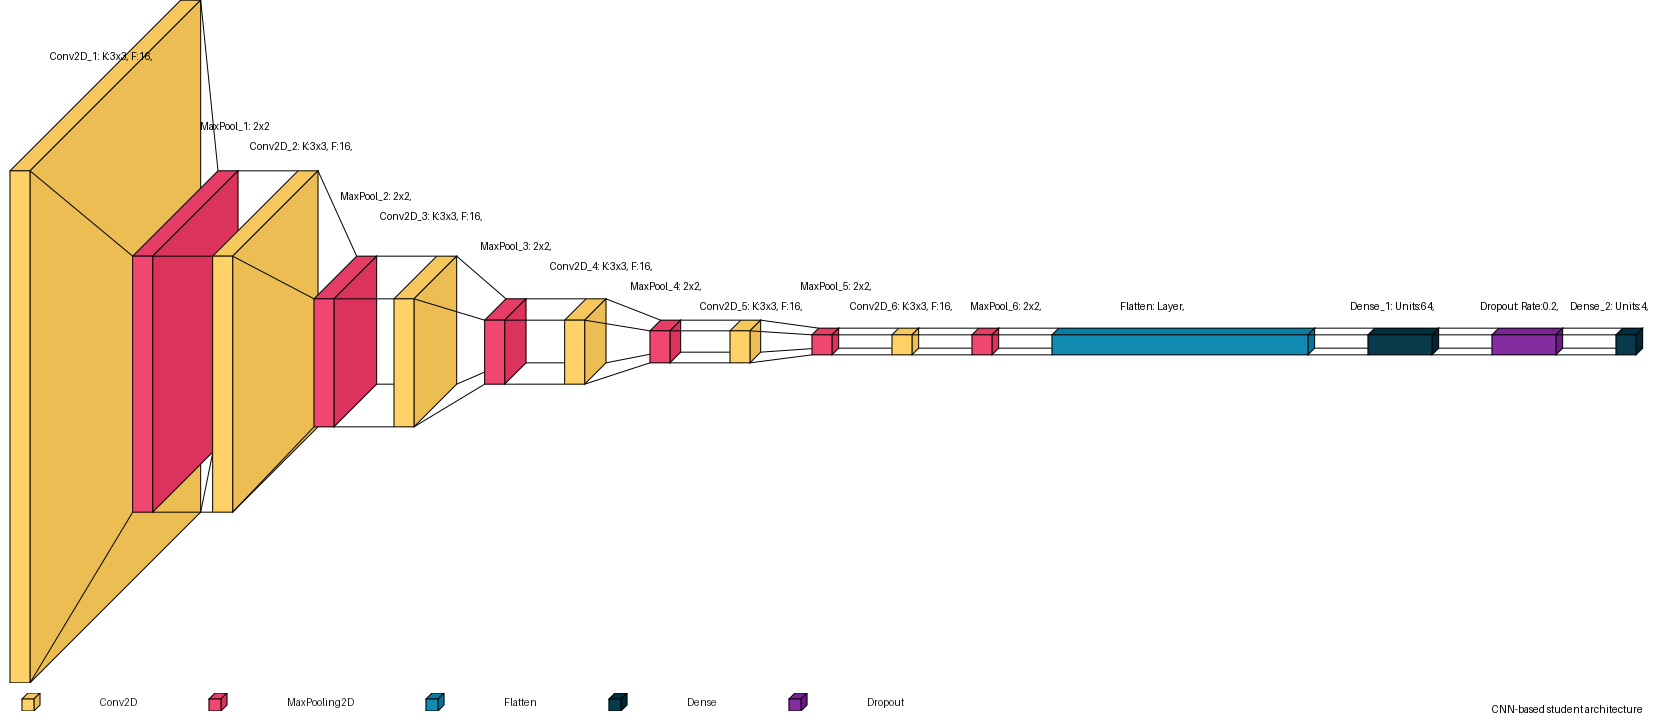

In [4]:
import visualkeras
from tensorflow.keras import layers, models
from PIL import Image, ImageFont, ImageDraw

# Define the model
input_shape = (256, 256, 3)

student = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_1'),
    layers.MaxPooling2D((2, 2), name='MaxPool_1'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_2'),
    layers.MaxPooling2D((2, 2), name='MaxPool_2'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_3'),
    layers.MaxPooling2D((2, 2), name='MaxPool_3'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_4'),
    layers.MaxPooling2D((2, 2), name='MaxPool_4'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_5'),
    layers.MaxPooling2D((2, 2), name='MaxPool_5'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_6'),
    layers.MaxPooling2D((2, 2), name='MaxPool_6'),
    layers.Flatten(),
    layers.Dense(64, activation='relu', name='Dense_1'),
    layers.Dropout(0.2, name='Dropout'),
    layers.Dense(4, activation='softmax', name='Dense_2')
], name='student')

# Create and save the model visualization without labels
image_path = "model_visualization.png"
visualkeras.layered_view(
    student,
    legend=True,  # Include legend
    scale_xy=2,   # Scale for better clarity
    scale_z=1,    # Scale for depth
    spacing=60,   # Adjust spacing
    to_file=image_path  # Save to file
)

# Load the generated image using PIL
img = Image.open(image_path)
draw = ImageDraw.Draw(img)

# Define layer details for custom labels (kernel size, filters, pooling size)
layer_details = {
    'Conv2D_1': 'K:3x3, F:16,',
    'MaxPool_1': '2x2',
    'Conv2D_2': 'K:3x3, F:16,',
    'MaxPool_2': '2x2,',
    'Conv2D_3': 'K:3x3, F:16,',
    'MaxPool_3': '2x2,',
    'Conv2D_4': 'K:3x3, F:16,',
    'MaxPool_4': '2x2,',
    'Conv2D_5': 'K:3x3, F:16,',
    'MaxPool_5': '2x2,',
    'Conv2D_6': 'K:3x3, F:16,',
    'MaxPool_6': '2x2,',
    'Flatten' : 'Layer,',
    'Dense_1': 'Units:64,',
    'Dropout': 'Rate:0.2,',
    'Dense_2': 'Units:4,'
}

# Adjust label positions dynamically for horizontal layout
label_positions = {
    'Conv2D_1': (50, 50),
    'MaxPool_1': (200, 100),
    'Conv2D_2': (250, 100),
    'MaxPool_2': (340, 130),
    'Conv2D_3': (380, 130),
    'MaxPool_3': (480, 140),
    'Conv2D_4': (550, 140),
    'MaxPool_4': (630, 140),
    'Conv2D_5': (700, 140),
    'MaxPool_5': (800, 100),
    'Conv2D_6': (850, 100),
    'MaxPool_6': (970, 80),
    'Flatten': (1120,60),
    'Dense_1': (1350, 40),
    'Dropout': (1480, 20),
    'Dense_2': (1570, 0)
}

# Define font for labels
font = ImageFont.load_default()

# Add the labels to the image at the specified positions
y_offset = 0  # Variable to adjust vertical spacing if needed
for layer_name, label in layer_details.items():
    x, y = label_positions.get(layer_name, (0, 0))  # Default to (0,0) if not found
    y += y_offset  # Apply offset to avoid overlap vertically
    draw.text((x, y), f"{layer_name}: {label}", font=font, fill="black")
    y_offset += 20  # Increase y_offset to ensure vertical spacing

# Add the model name at the bottom-right corner
text = "CNN-based student architecture"
bbox = draw.textbbox((0, 0), text, font=font)  # Get the bounding box
text_width, text_height = bbox[2] - bbox[0], bbox[3] - bbox[1]
image_width, image_height = img.size
draw.text((image_width - text_width - 10, image_height - text_height - 10), text, font=font, fill="black")

# Save the updated image with labels
image_path_with_labels = "model_visualization_with_labels.png"
img.save(image_path_with_labels)

# Display the saved image
from IPython.display import Image, display
display(Image(image_path_with_labels))


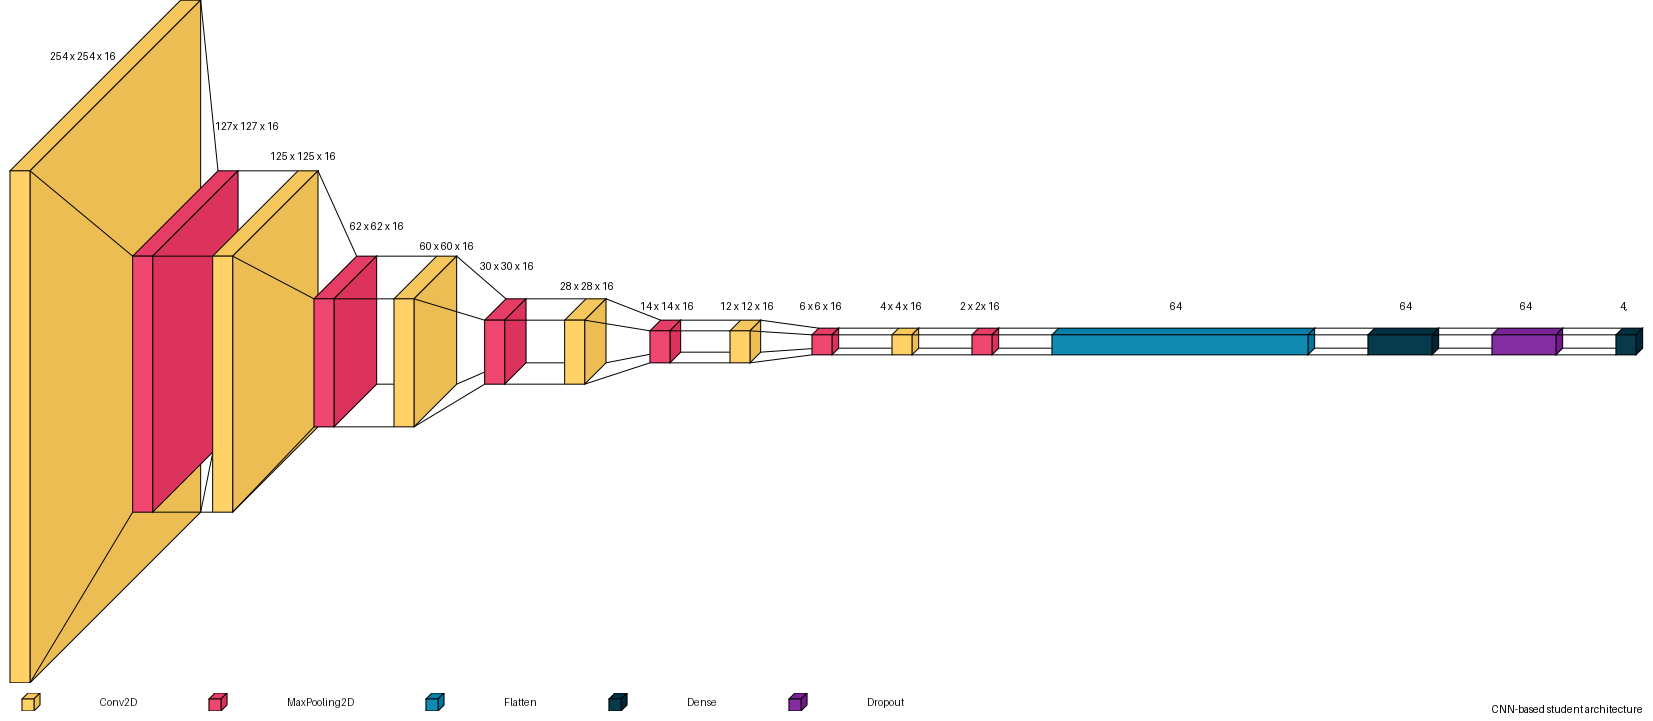

In [58]:
import visualkeras
from tensorflow.keras import layers, models
from PIL import Image, ImageFont, ImageDraw

# Define the model
input_shape = (256, 256, 3)

student = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_1'),
    layers.MaxPooling2D((2, 2), name='MaxPool_1'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_2'),
    layers.MaxPooling2D((2, 2), name='MaxPool_2'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_3'),
    layers.MaxPooling2D((2, 2), name='MaxPool_3'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_4'),
    layers.MaxPooling2D((2, 2), name='MaxPool_4'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_5'),
    layers.MaxPooling2D((2, 2), name='MaxPool_5'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_6'),
    layers.MaxPooling2D((2, 2), name='MaxPool_6'),
    layers.Flatten(),
    layers.Dense(64, activation='relu', name='Dense_1'),
    layers.Dropout(0.2, name='Dropout'),
    layers.Dense(4, activation='softmax', name='Dense_2')
], name='student')

# Create and save the model visualization without labels
image_path = "model_visualization.png"
visualkeras.layered_view(
    student,
    legend=True,  # Include legend
    scale_xy=2,   # Scale for better clarity
    scale_z=1,    # Scale for depth
    spacing=60,   # Adjust spacing
    to_file=image_path  # Save to file
)

# Load the generated image using PIL
img = Image.open(image_path)
draw = ImageDraw.Draw(img)

# Define layer details for custom labels (kernel size, filters, pooling size)
layer_details = {
    'Conv2D_1': '254 x 254 x 16',
    'MaxPool_1': '127x 127 x 16',
    'Conv2D_2': '125 x 125 x 16',
    'MaxPool_2': '62 x 62 x 16',
    'Conv2D_3': '60 x 60 x 16',
    'MaxPool_3': '30 x 30 x 16',
    'Conv2D_4': '28 x 28 x 16',
    'MaxPool_4': '14 x 14 x 16',
    'Conv2D_5': '12 x 12 x 16',
    'MaxPool_5': '6 x 6 x 16',
    'Conv2D_6': '4 x 4 x 16',
    'MaxPool_6': '2 x 2x 16',
    'Flatten' : '64',
    'Dense_1': '64',
    'Dropout': '64',
    'Dense_2': '4,'
}

# Adjust label positions dynamically for horizontal layout
label_positions = {
    'Conv2D_1': (50, 50),
    'MaxPool_1': (215, 100),
    'Conv2D_2': (270, 110),
    'MaxPool_2': (350, 160),
    'Conv2D_3': (420, 160),
    'MaxPool_3': (480, 160),
    'Conv2D_4': (560, 160),
    'MaxPool_4': (640, 160),
    'Conv2D_5': (720, 140),
    'MaxPool_5': (800, 120),
    'Conv2D_6': (880, 100),
    'MaxPool_6': (960, 80),
    'Flatten': (1170,60),
    'Dense_1': (1400, 40),
    'Dropout': (1520, 20),
    'Dense_2': (1620, 0)
}

# Define font for labels
font = ImageFont.load_default()

# Add the labels to the image at the specified positions
y_offset = 0  # Variable to adjust vertical spacing if needed
for layer_name, label in layer_details.items():
    x, y = label_positions.get(layer_name, (0, 0))  # Default to (0,0) if not found
    y += y_offset  # Apply offset to avoid overlap vertically
    draw.text((x, y), f"{label}", font=font, fill="black")
    y_offset += 20  # Increase y_offset to ensure vertical spacing

# Add the model name at the bottom-right corner
text = "CNN-based student architecture"
bbox = draw.textbbox((0, 0), text, font=font)  # Get the bounding box
text_width, text_height = bbox[2] - bbox[0], bbox[3] - bbox[1]
image_width, image_height = img.size
draw.text((image_width - text_width - 10, image_height - text_height - 10), text, font=font, fill="black")

# Save the updated image with labels
image_path_with_labels = "model_visualization_with_kernel_filters.png"
img.save(image_path_with_labels)

# Display the saved image
from IPython.display import Image, display
display(Image(image_path_with_labels))


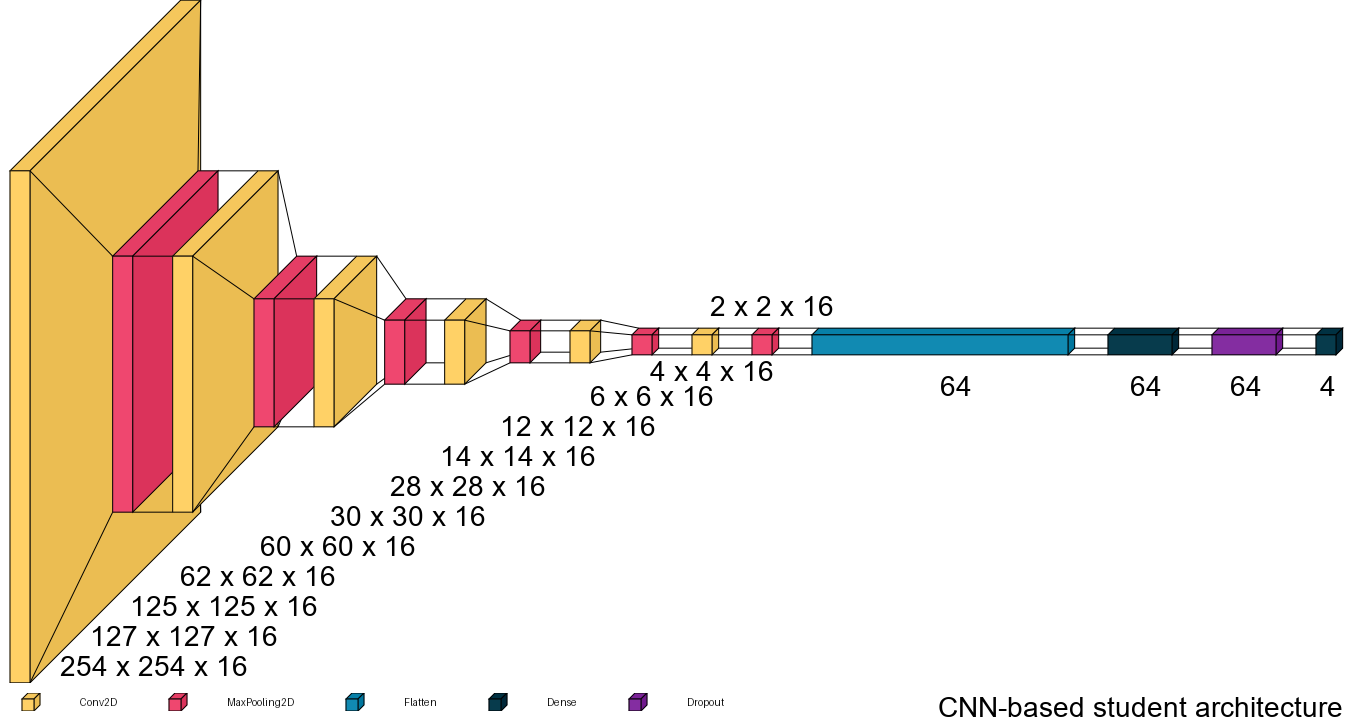

In [5]:
import visualkeras
from tensorflow.keras import layers, models
from PIL import Image, ImageFont, ImageDraw

# Define the model
input_shape = (256, 256, 3)

student = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_1'),
    layers.MaxPooling2D((2, 2), name='MaxPool_1'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_2'),
    layers.MaxPooling2D((2, 2), name='MaxPool_2'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_3'),
    layers.MaxPooling2D((2, 2), name='MaxPool_3'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_4'),
    layers.MaxPooling2D((2, 2), name='MaxPool_4'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_5'),
    layers.MaxPooling2D((2, 2), name='MaxPool_5'),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same', name='Conv2D_6'),
    layers.MaxPooling2D((2, 2), name='MaxPool_6'),
    layers.Flatten(),
    layers.Dense(64, activation='relu', name='Dense_1'),
    layers.Dropout(0.2, name='Dropout'),
    layers.Dense(4, activation='softmax', name='Dense_2')
], name='student')

# Create and save the model visualization without labels
image_path = "model_visualization.png"

visualkeras.layered_view(
    student,
    legend=True,  # Include legend
    scale_xy=2,   # Scale for better clarity
    scale_z=1,    # Scale for depth
    spacing=40,   # Adjust spacing
    to_file=image_path  # Save to file
)

# Load the generated image using PIL
img = Image.open(image_path)
draw = ImageDraw.Draw(img)

# Define layer details for custom labels (kernel size, filters, pooling size)
layer_details = {
    'Conv2D_1': '254 x 254 x 16',
    'MaxPool_1': '127 x 127 x 16',
    'Conv2D_2': '125 x 125 x 16',
    'MaxPool_2': '62 x 62 x 16',
    'Conv2D_3': '60 x 60 x 16',
    'MaxPool_3': '30 x 30 x 16',
    'Conv2D_4': '28 x 28 x 16',
    'MaxPool_4': '14 x 14 x 16',
    'Conv2D_5': '12 x 12 x 16',
    'MaxPool_5': '6 x 6 x 16',
    'Conv2D_6': '4 x 4 x 16',
    'MaxPool_6': '2 x 2 x 16',
    'Flatten': '64',
    'Dense_1': '64',
    'Dropout': '64',
    'Dense_2': '4'
}

# Adjust label positions dynamically for horizontal layout
label_positions = {
    'Conv2D_1': (60, 650),
    'MaxPool_1': (90, 590),
    'Conv2D_2': (130, 530),
    'MaxPool_2': (180, 470),
    'Conv2D_3': (260, 410),
    'MaxPool_3': (330,350),
    'Conv2D_4': (390, 290),
    'MaxPool_4': (440, 230),
    'Conv2D_5': (500, 170),
    'MaxPool_5': (590, 110),
    'Conv2D_6': (650, 55),
    'MaxPool_6': (710, -40),
    'Flatten': (940, 10),
    'Dense_1': (1130, -20),
    'Dropout': (1230, -50),
    'Dense_2': (1320, -80)
}

# Load a custom font with a larger size
font_path = "D:/Downloads/arial-font/arial.ttf"  # Path to the font file
font = ImageFont.truetype(font_path, size=28)  # Increase the size (e.g., 20 or any desired size)

# Add the labels to the image at the specified positions
y_offset = 0  # Variable to adjust vertical spacing if needed

for layer_name, label in layer_details.items():
    x, y = label_positions.get(layer_name, (0, 0))  # Default to (0,0) if not found
    y += y_offset  # Apply offset to avoid overlap vertically
    draw.text((x, y), f"{label}", font=font, fill="black")
    y_offset += 30  # Increase y_offset to ensure vertical spacing

# Add the model name at the bottom-right corner with larger text
text = "CNN-based student architecture"
bbox = draw.textbbox((0, 0), text, font=font)  # Get the bounding box
text_width, text_height = bbox[2] - bbox[0], bbox[3] - bbox[1]
image_width, image_height = img.size
draw.text((image_width - text_width - 10, image_height - text_height - 10), text, font=font, fill="black")

# Save the updated image with labels
image_path_with_labels = "model_visualization_with_kernel_filters.png"
img.save(image_path_with_labels)

# Display the saved image
from IPython.display import Image, display
display(Image(image_path_with_labels))


In [3]:
import tensorflow as tf
import numpy as np
from tabulate import tabulate

# Function to calculate MSE and RMSE
def calculate_errors(model_name, model, test_set):
    print("Calculating errors for", model_name, "model...")
    # Evaluate the model on the test set
    loss, _ = model.evaluate(test_set)
    print("Model Loss:", loss)

    num_samples = len(test_set)
    mse_total = 0.0

    for _ in range(num_samples):
        # Get batch of test data
        X_test_batch, y_test_batch = test_set.next()

        # Make predictions using the model
        predictions_batch = model.predict(X_test_batch)

        # Calculate Mean Squared Error for this batch
        mse_batch = np.mean(np.square(predictions_batch - y_test_batch))

        # Add to total MSE
        mse_total += mse_batch

    # Calculate average MSE across all batches
    mse = mse_total / num_samples
    print("Mean Squared Error:", mse)

    # Calculate RMSE
    rmse = np.sqrt(mse)
    print("Root Mean Squared Error:", rmse)
    return loss, mse, rmse

# # Load and calculate errors for the teacher model
# teacher_model = tf.keras.models.load_model('/content/drive/MyDrive/Thesis Data FALL 2023(Maimunul & Samir)/Maimunul(201001312) Rice Leaf Disease work /Updatework/BestTeacher.h5')
# teacher_loss, teacher_mse, teacher_rmse = calculate_errors("Distiller CNN-based Teacher", teacher_model, test_set)

# Load and calculate errors for the student model
student_model = tf.keras.models.load_model(r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\DenseNet121_To_Student\NewStudentAccuracy.h5')
student_loss, student_mse, student_rmse = calculate_errors("CNN based Student", student_model, test_set)

models = {
    'VGG16_Teacher': r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\VGG16_To_Student\VGG16Teacher_distil_T10.h5',
    'CNN_based_Teacher' : r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\Teacher_To_Student\CNNbasedTeacher_distil_T10.h5',
    'InceptionV3_Teacher': r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\InceptionV3_TO_Student\INCEPTIONV3_Teacher_distil2_T10_52724.h5',
    'DenseNet121_Teacher': r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\DenseNet121_To_Student\DenseNet121Teacher_distil2_T10.h5',
    'MobileNetV2_Teacher': r'C:\Users\User\Desktop\MSERMSE_Temperature\New_folder\NEWWORK\MobileNetV2_To_Student\MobileNetV2Teacher_distil2_T10_52724.h5'
}

# Initialize variables to store the best model and its corresponding MSE and RMSE
best_model_name = None
best_mse = float('inf')
best_rmse = float('inf')

# Initialize table data
table_data = []

# Iterate over each distiller model
for temp, model_path in models.items():
    # Load the distiller model
    distiller_model = tf.keras.models.load_model(model_path)

    # Calculate errors for the distiller model
    distiller_loss, distiller_mse, distiller_rmse = calculate_errors("Distiller " + temp, distiller_model, test_set)

    # Check if this model has the lowest MSE and RMSE so far
    if distiller_mse < best_mse:
        best_model_name = "Distiller " + temp
        best_mse = distiller_mse
        best_rmse = distiller_rmse
    elif distiller_mse == best_mse and distiller_rmse < best_rmse:
        best_model_name = "Distiller " + temp
        best_rmse = distiller_rmse

    # Calculate differences in MSE and RMSE between this model and the student model
    mse_difference = distiller_mse - student_mse
    rmse_difference = distiller_rmse - student_rmse

    # Append results to table data
    table_data.append(["Distiller " + temp, distiller_loss, distiller_mse, distiller_rmse, mse_difference, rmse_difference])

# Add rows for the teacher and student models
table_data.extend([
    #["Teacher", teacher_loss, teacher_mse, teacher_rmse, teacher_mse - student_mse, teacher_rmse - student_rmse],
    ["Student", student_loss, student_mse, student_rmse, 0, 0],
    ["Best Distiller", "", best_mse, best_rmse, best_mse - student_mse, best_rmse - student_rmse]
])

# Print table
print(tabulate(table_data, headers=["Model", "Loss", "MSE", "RMSE", "MSE Difference", "RMSE Difference"], tablefmt="grid"))




Calculating errors for CNN based Student model...

19/19 [==============================] - 3s 104ms/step - loss: 0.5833 - accuracy: 0.7782
Model Loss: 0.5833341479301453
1/1 [==============================] - 0s 115ms/step
Mean Squared Error: 0.07933752630886279
Root Mean Squared Error: 0.28166917884082165
Calculating errors for Distiller VGG16_Teacher model...
19/19 [==============================] - 2s 89ms/step - loss: 0.0623 - accuracy: 0.9815
Model Loss: 0.06229010969400406
1/1 [==============================] - 0s 110ms/step
Mean Squared Error: 0.007733685564935992
Root Mean Squared Error: 0.08794137572801548
Calculating errors for Distiller CNN_based_Teacher model...
19/19 [==============================] - 2s 87ms/step - loss: 0.1550 - accuracy: 0.9479
Model Loss: 0.15502892434597015
1/1 [==============================] - 0s 117ms/step
Mean Squared Error: 0.019524543546140194
Root Mean Squared Error: 0.13973025279494844
Calculating errors for Distiller InceptionV3_Teacher mo

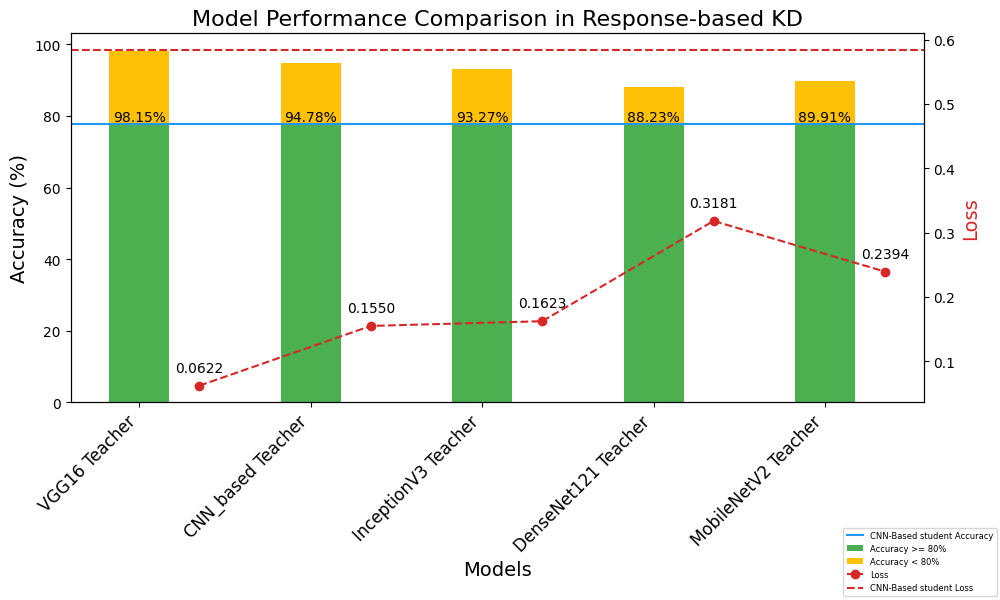

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = [ 'VGG16 Teacher','CNN_based Teacher', 'InceptionV3 Teacher',  'DenseNet121 Teacher', 'MobileNetV2 Teacher']
accuracies = [98.15, 94.78, 93.27, 88.23, 89.91]
losses = [0.0622, 0.1550, 0.1623, 0.3181, 0.2394]
student_accuracy = 77.81
student_loss = 0.5833
# Set up figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotting accuracy as bars
bar_width = 0.35
bar_positions = np.arange(len(models))

# Separate bars into two colors based on accuracy
bars_color1 = [min(acc, student_accuracy) for acc in accuracies]
bars_color2 = [max(acc - student_accuracy, 0) for acc in accuracies]

# Plotting bars with two colors
bars1 = ax1.bar(bar_positions, bars_color1, bar_width, label='Accuracy >= 80%', color='#4CAF50')  # Green color
bars2 = ax1.bar(bar_positions, bars_color2, bar_width, bottom=bars_color1, label='Accuracy < 80%', color='#FFC107')  # Amber color

# Adding labels and title
ax1.set_xlabel('Models', fontsize=14)
ax1.set_ylabel('Accuracy (%)', color='black', fontsize=14)
ax1.set_title('Model Performance Comparison in Response-based KD', fontsize=16)
ax1.set_xticks(bar_positions)
ax1.set_xticklabels(models, rotation=45, ha="right", fontsize=12)

# Creating a second y-axis for losses
ax2 = ax1.twinx()
line = ax2.plot(bar_positions + bar_width, losses, marker='o', color='#d62728', label='Loss', linestyle='--')

# Adding labels for the second y-axis
ax2.set_ylabel('Loss', color='#d62728', fontsize=14)

# Adding accuracy values on top of each bar
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{acc:.2f}%',
             ha='center', va='bottom', color='black', fontsize=10)

# Adding annotations for loss values
for i, txt in enumerate(losses):
    ax2.annotate(f'{txt:.4f}', (bar_positions[i] + bar_width, losses[i]), textcoords="offset points", xytext=(0, 10), ha='center')

# Differentiating Proposed Student Network with horizontal lines
ax1.axhline(y=student_accuracy, color='#2196F3', linestyle='-', label='CNN-Based student Accuracy')  # Blue color
ax2.axhline(y=student_loss, color='#d62728', linestyle='--', label='CNN-Based student Loss')

# Adjusting layout
fig.tight_layout()

# Displaying the legend in the upper left corner
fig.legend(loc='lower right', fontsize=6)

# Show the plot
plt.show()


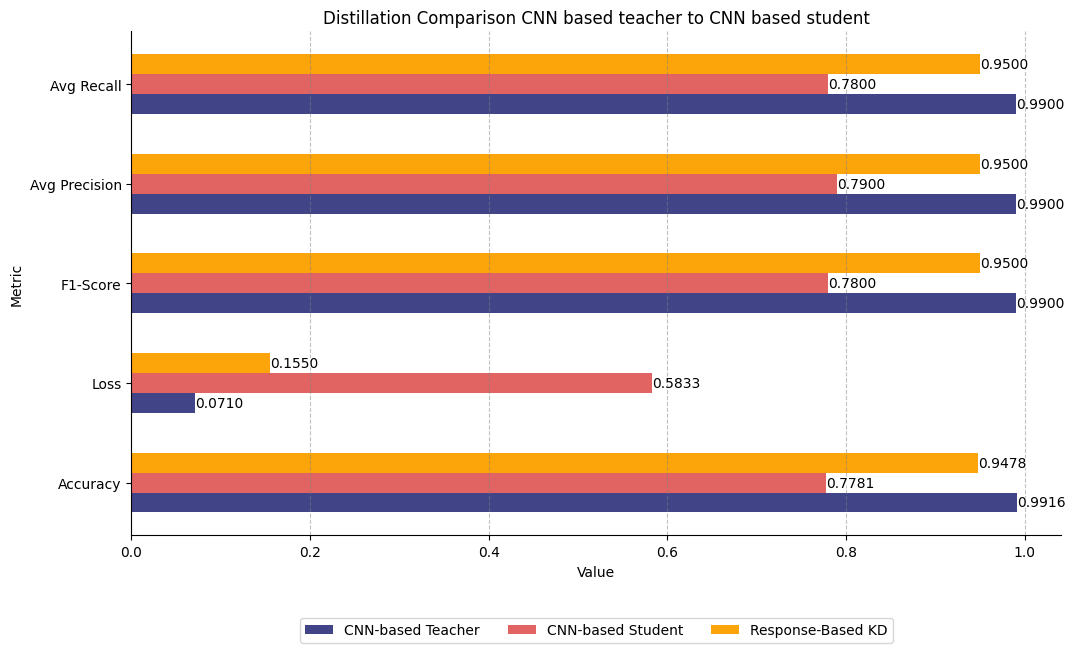

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# Data from the table
cnn_based_teacher_accuracy = 0.9916
cnn_based_student_accuracy = 0.7781
response_based_kd_accuracy = 0.9478

cnn_based_teacher_loss = 0.0710
cnn_based_student_loss = 0.5833
response_based_kd_loss = 0.1550

cnn_based_teacher_f1 = 0.99
cnn_based_student_f1 = 0.78
response_based_kd_f1 = 0.95

cnn_based_teacher_precision = 0.99
cnn_based_student_precision = 0.79
response_based_kd_precision = 0.95

cnn_based_teacher_recall = 0.99
cnn_based_student_recall = 0.78
response_based_kd_recall = 0.95

# Create the bar chart with improved styling
fig, ax = plt.subplots(figsize=(12, 8))

# Metrics as subplots
width = 0.2  # Reduce the width to provide space between bars
y = np.array(range(5))

# CNN-based Teacher (first bar)
bars_teacher = ax.barh(y, [cnn_based_teacher_accuracy, cnn_based_teacher_loss, cnn_based_teacher_f1,
                           cnn_based_teacher_precision, cnn_based_teacher_recall],
                       width, label='CNN-based Teacher', color=plt.cm.viridis(0.2))

# CNN-based Student (second bar)
bars_student = ax.barh([i + width for i in y], [cnn_based_student_accuracy, cnn_based_student_loss, cnn_based_student_f1,
                                                cnn_based_student_precision, cnn_based_student_recall],
                       width, label='CNN-based Student', color=plt.cm.plasma(0.6))

# Response-Based KD (third bar)
bars_kd = ax.barh([i + 2 * width for i in y], [response_based_kd_accuracy, response_based_kd_loss, response_based_kd_f1,
                                                response_based_kd_precision, response_based_kd_recall],
                  width, label='Response-Based KD', color=plt.cm.inferno(0.8))

# Labels and title
ax.set_xlabel('Value')
ax.set_ylabel('Metric')
ax.set_title('Distillation Comparison CNN based teacher to CNN based student')
ax.set_yticks([i + width for i in y])
ax.set_yticklabels(['Accuracy', 'Loss', 'F1-Score', 'Avg Precision', 'Avg Recall'])

# Add data labels on top of the bars with 3D-like effect
def add_labels(bars):
    for bar in bars:
        yval = bar.get_y() + bar.get_height() / 2
        xval = bar.get_width()
        ax.text(xval, yval, f'{xval:.4f}', ha='left', va='center', fontsize=10, fontweight='bold', color='white')

add_labels(bars_teacher)
add_labels(bars_student)
add_labels(bars_kd)

# Add data labels at the end of each bar
def add_data_labels(bars):
    for bar in bars:
        xval = bar.get_width()
        ax.text(xval, bar.get_y() + bar.get_height() / 2, f'{xval:.4f}', ha='left', va='center', fontsize=10, color='black')

add_data_labels(bars_teacher)
add_data_labels(bars_student)
add_data_labels(bars_kd)

# Add 3D-like effect
ax.grid(False)
ax.xaxis.grid(True, linestyle='--', color='gray', alpha=0.5)
ax.yaxis.grid(False)

# Customize spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Move the legend below the chart with improved spacing
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=10)

# Adjust layout to provide space for the legend
plt.subplots_adjust(bottom=0.25)

# Show the plot
plt.show()


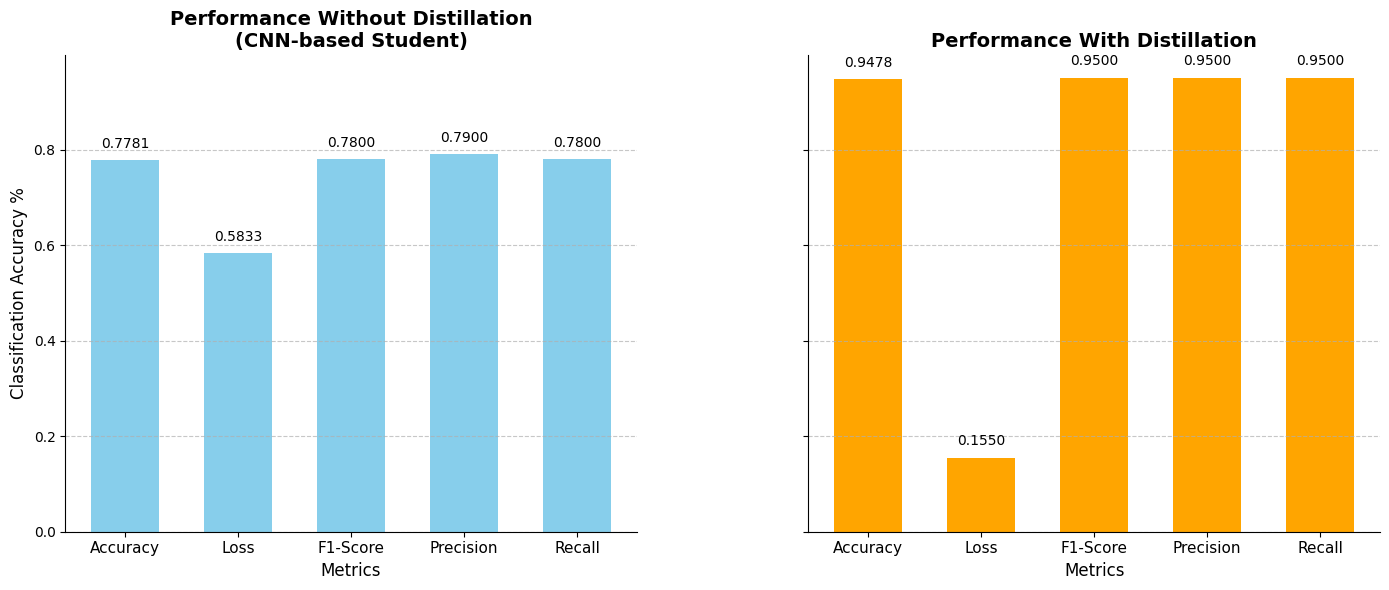

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the models
without_distillation = [0.7781, 0.5833, 0.78, 0.79, 0.78]  # CNN-based Student (Without Distillation)
with_distillation = [0.9478, 0.1550, 0.95, 0.95, 0.95]  # Response-based KD (With Distillation)

metrics = ['Accuracy', 'Loss', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metrics))  # Position of bars

# Create subplots with two columns
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 6), sharey=True)

# First subplot: Without Distillation
bars_without = ax1.bar(x, without_distillation, color='skyblue', width=0.6)

# Add value labels
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.4f}', ha='center', va='bottom', fontsize=10)

add_labels(ax1, bars_without)

# Configure the first subplot
ax1.set_title('Performance Without Distillation\n(CNN-based Student)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Metrics', fontsize=12)
ax1.set_ylabel('Classification Accuracy %', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Second subplot: With Distillation
bars_with = ax2.bar(x, with_distillation, color='orange', width=0.6)

# Add value labels
add_labels(ax2, bars_with)

# Configure the second subplot
ax2.set_title('Performance With Distillation', fontsize=14, fontweight='bold')
ax2.set_xlabel('Metrics', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics, fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)  # Adjust space between the subplots

# Show the plot
plt.show()


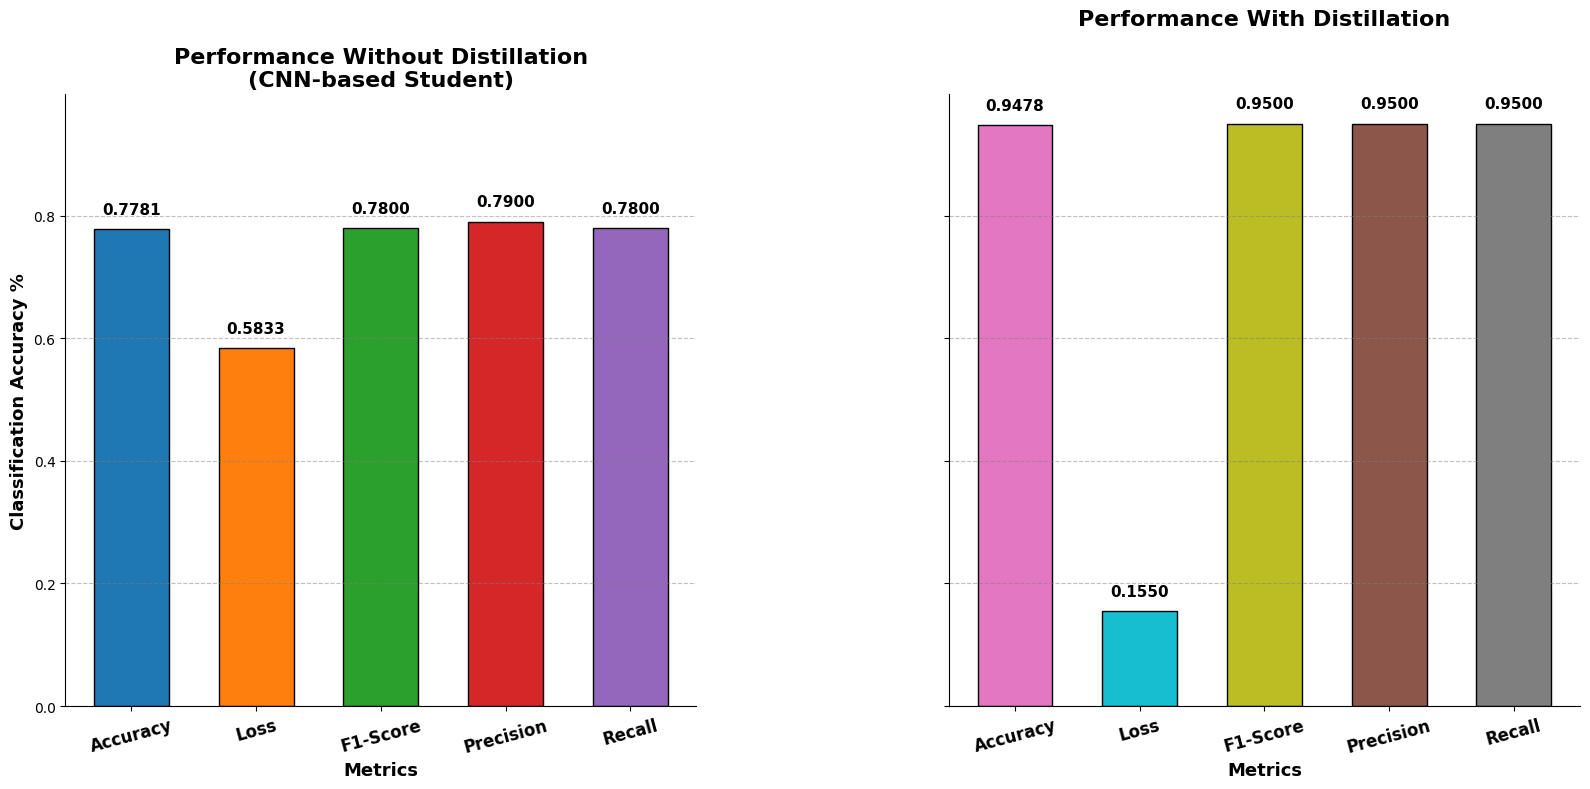

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the models
without_distillation = [0.7781, 0.5833, 0.78, 0.79, 0.78]  # CNN-based Student (Without Distillation)
with_distillation = [0.9478, 0.1550, 0.95, 0.95, 0.95]  # Response-based KD (With Distillation)

metrics = ['Accuracy', 'Loss', 'F1-Score', 'Precision', 'Recall']
x = np.arange(len(metrics))  # Position of bars

# Create subplots with two columns
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(16, 8), sharey=True)

# Define improved colors
colors_without = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']  # Gradient for Without Distillation
colors_with = ['#e377c2', '#17becf', '#bcbd22', '#8c564b', '#7f7f7f']  # Gradient for With Distillation

# First subplot: Without Distillation
bars_without = ax1.bar(x, without_distillation, color=colors_without, width=0.6, edgecolor='black', linewidth=1)

# Add value labels with bold font and formatting
def add_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f'{height:.4f}', 
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

add_labels(ax1, bars_without)

# Configure the first subplot
ax1.set_title('Performance Without Distillation\n(CNN-based Student)', fontsize=16, fontweight='bold', color='black')
ax1.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax1.set_ylabel('Classification Accuracy %', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, fontsize=12, fontweight='bold', rotation=15)
ax1.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

# Second subplot: With Distillation
bars_with = ax2.bar(x, with_distillation, color=colors_with, width=0.6, edgecolor='black', linewidth=1)

# Add value labels for the second chart
add_labels(ax2, bars_with)

# Configure the second subplot
ax2.set_title('Performance With Distillation', fontsize=16, fontweight='bold', color='black',pad=50)
ax2.set_xlabel('Metrics', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics, fontsize=12, fontweight='bold', rotation=15)
ax2.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Add annotations for context
ax1.text(-0.7, 1.05,'', fontsize=12, fontstyle='italic', color='gray', transform=ax1.transAxes)
ax2.text(-0.7, 1.05,'', fontsize=12, fontstyle='italic', color='gray', transform=ax2.transAxes)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.4)  # Adjust space between the subplots

# Show the plot
plt.show()


In [3]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd
from tabulate import tabulate

# Paths to the model

models = {
    'VGG16_Teacher': r'VGG16_To_Student\VGG16Teacher_distil_T10.h5',
    'CNN_based_Teacher' : r'Teacher_To_Student\CNNbasedTeacher_distil_T10.h5',
    'InceptionV3_Teacher': r'InceptionV3_TO_Student\INCEPTIONV3_Teacher_distil2_T10_52724.h5',
    'DenseNet121_Teacher': r'DenseNet121_To_Student\DenseNet121Teacher_distil2_T10.h5',
    'MobileNetV2_Teacher': r'MobileNetV2_To_Student\MobileNetV2Teacher_distil2_T10_52724.h5',
    'CNN_based_Student' : r'Teacher_To_Student\NewStudentAccuracy.h5'
}



# Initialize a DataFrame to store the results
results = pd.DataFrame(columns=['Model', 'Loss', 'Accuracy', 'MSE', 'RMSE', 'MSE Difference', 'RMSE Difference'])

# Function to calculate RMSE
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Function to calculate errors
def calculate_errors(model_name, model, test_set):
    print(f"Calculating errors for {model_name} model...")

    # Evaluate the model on the test set
    loss, accuracy = model.evaluate(test_set, steps=test_set.samples // test_set.batch_size + 1, verbose=0)
    print(f"Model Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

    # Make predictions
    predictions = model.predict(test_set, steps=test_set.samples // test_set.batch_size + 1, verbose=0)
    true_labels = test_set.classes
    true_labels_one_hot = tf.keras.utils.to_categorical(true_labels, num_classes=test_set.num_classes)

    # Calculate MSE and RMSE
    mse = mean_squared_error(true_labels_one_hot, predictions)
    rmse = calculate_rmse(true_labels_one_hot, predictions)
    return loss, accuracy, mse, rmse

# Evaluate the student model separately
student_loss, student_accuracy, student_mse, student_rmse = calculate_errors("CNN based Student", load_model(models['CNN_based_Student']), test_set)

# Evaluate each model and collect results
for model_name, model_path in models.items():
    if model_name == 'CNN_based_Student':
        continue  # Skip the student model here as it's already evaluated

    # Load the model
    model = load_model(model_path)

    # Calculate errors for the model
    loss, accuracy, mse, rmse = calculate_errors(model_name, model, test_set)

    # Calculate differences in MSE and RMSE between this model and the student model
    mse_difference = mse - student_mse
    rmse_difference = rmse - student_rmse

    # Append results to the DataFrame using pd.concat
    results = pd.concat([results, pd.DataFrame([{
        'Model': model_name,
        'Loss': loss,
        'Accuracy': accuracy,
        'MSE': mse,
        'RMSE': rmse,
        'MSE Difference': mse_difference,
        'RMSE Difference': rmse_difference
    }])], ignore_index=True)

# Add a row for the student model
results = pd.concat([results, pd.DataFrame([{
    'Model': 'CNN based Student',
    'Loss': student_loss,
    'Accuracy': student_accuracy,
    'MSE': student_mse,
    'RMSE': student_rmse,
    'MSE Difference': 0,
    'RMSE Difference': 0
}])], ignore_index=True)

# Display the results table
print(tabulate(results, headers='keys', tablefmt='grid', showindex=False))




Calculating errors for CNN based Student model...

Model Loss: 0.5833, Accuracy: 0.7782
Calculating errors for VGG16_Teacher model...
Model Loss: 0.0623, Accuracy: 0.9815


C:\Users\My Pc\AppData\Local\Temp\ipykernel_6260\1224786220.py:66: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([{


Calculating errors for CNN_based_Teacher model...
Model Loss: 0.1550, Accuracy: 0.9479
Calculating errors for InceptionV3_Teacher model...
Model Loss: 0.1623, Accuracy: 0.9328
Calculating errors for DenseNet121_Teacher model...
Model Loss: 0.2394, Accuracy: 0.8992
Calculating errors for MobileNetV2_Teacher model...
Model Loss: 0.3182, Accuracy: 0.8824
+---------------------+-----------+------------+----------+----------+------------------+-------------------+
| Model               |      Loss |   Accuracy |      MSE |     RMSE |   MSE Difference |   RMSE Difference |
+=====================+===========+============+==========+==========+==================+===================+
| VGG16_Teacher       | 0.0622901 |   0.981513 | 0.373401 | 0.611065 |        0.0630233 |         0.0539499 |
+---------------------+-----------+------------+----------+----------+------------------+-------------------+
| CNN_based_Teacher   | 0.155029  |   0.947899 | 0.350976 | 0.592432 |        0.0405987 |       

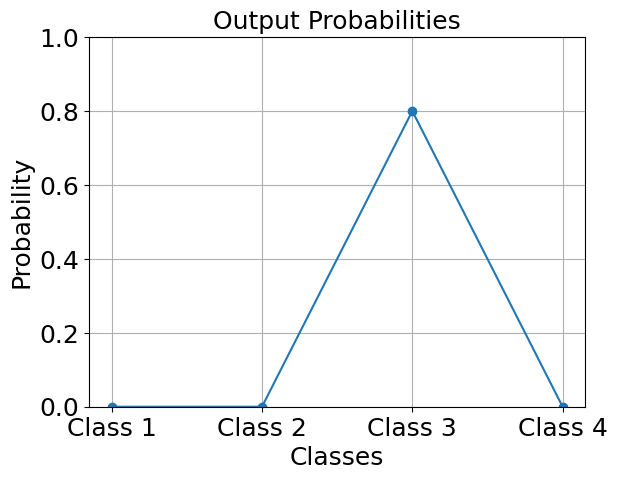

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the line plot
categories = ['Class 1', 'Class 2', 'Class 3', 'Class 4']
values = [0, 0, 0.8, 0]  # Adjust the values as needed

# Create a line plot
plt.plot(categories, values, marker='o', linestyle='-')

# Set the title and labels
plt.title('Output Probabilities', fontsize=18)
plt.xlabel('Classes', fontsize=18)
plt.ylabel('Probability', fontsize=18)

# Adjust the font size of x-axis category labels
plt.xticks(fontsize=18)  # Increase the font size of the category labels
plt.yticks(fontsize=18)  # Adjust y-axis tick label size if needed

# Set y-axis limits to ensure visibility of the line
plt.ylim(0, 1)

# Show the plot
plt.grid(True)
plt.show()


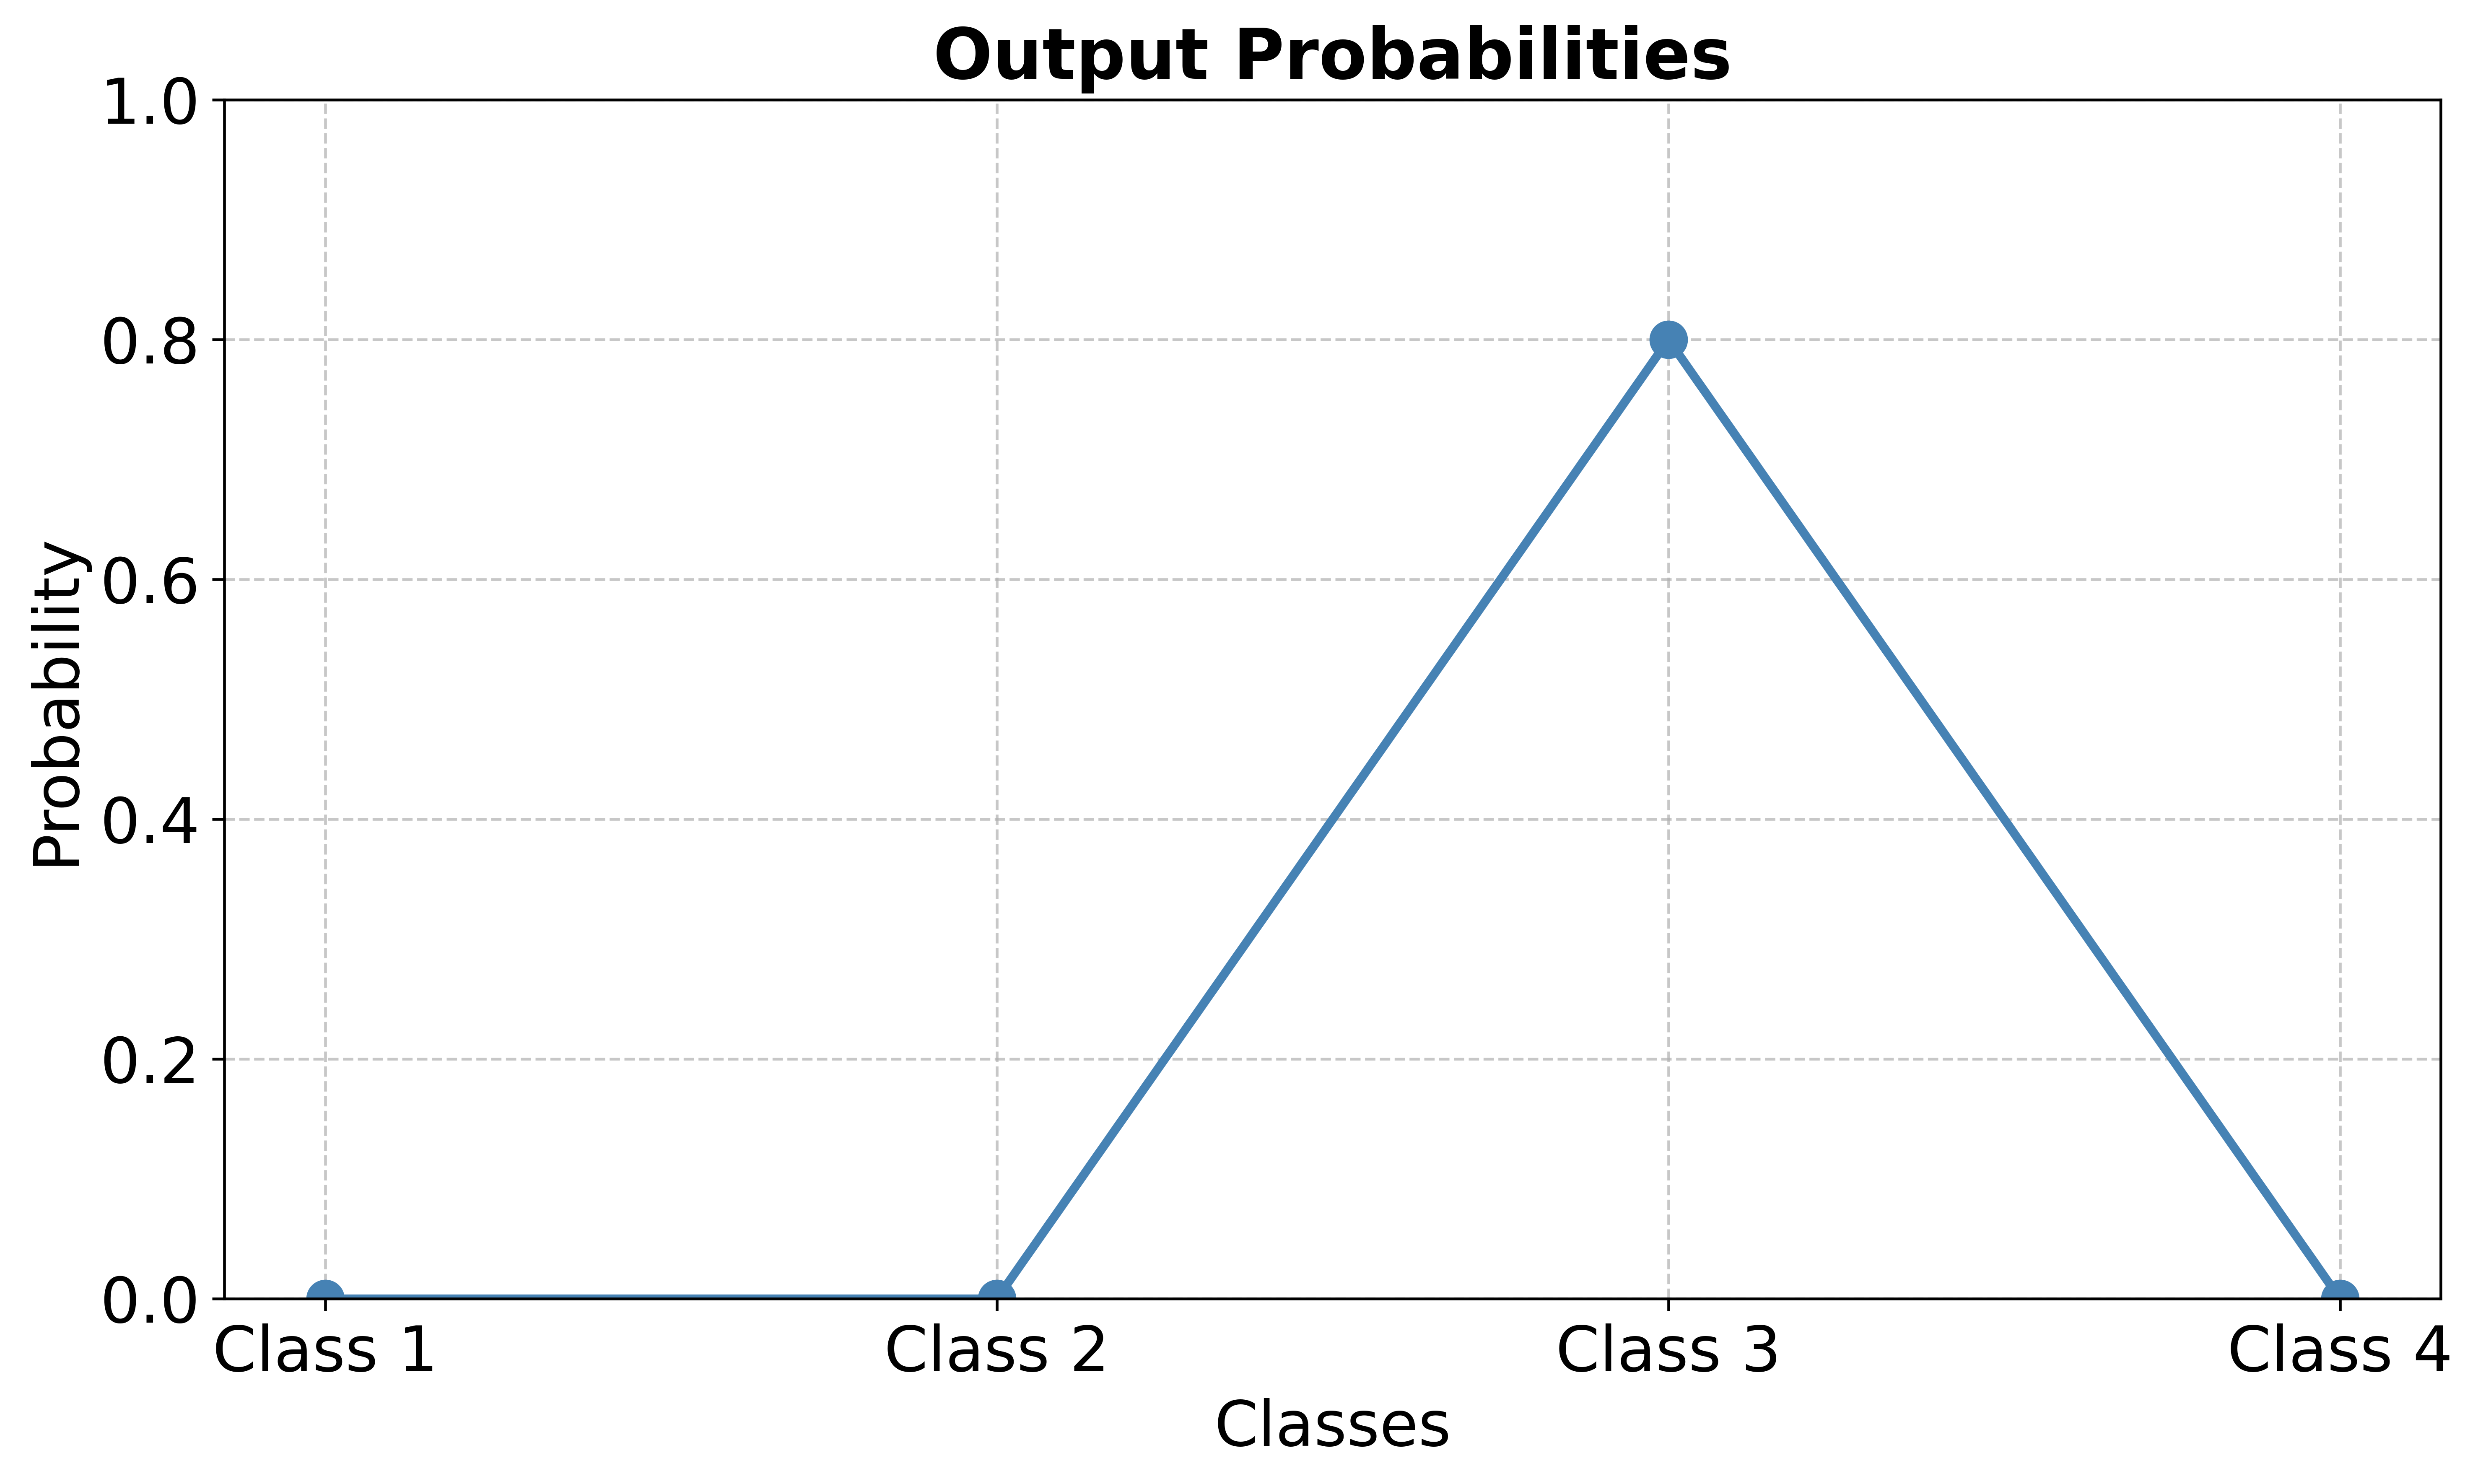

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the line plot
categories = ['Class 1', 'Class 2', 'Class 3', 'Class 4']
values = [0, 0, 0.8, 0]  # Adjust the values as needed

# Create a high-resolution figure
plt.figure(figsize=(10, 6), dpi=600)

# Create a line plot
plt.plot(categories, values, marker='o', linestyle='-', linewidth=2.5, markersize=10, color='steelblue')

# Set the title and labels
plt.title('Output Probabilities', fontsize=20, fontweight='bold')
plt.xlabel('Classes', fontsize=18)
plt.ylabel('Probability', fontsize=18)

# Adjust the font size of x-axis category labels
plt.xticks(fontsize=18)  # Increase the font size of the category labels
plt.yticks(fontsize=18)  # Adjust y-axis tick label size if needed

# Set y-axis limits to ensure visibility of the line
plt.ylim(0, 1)

# Show the plot with grid
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save the figure in high resolution (600 DPI)
plt.savefig('output_probabilities_600dpi.png', dpi=600, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()

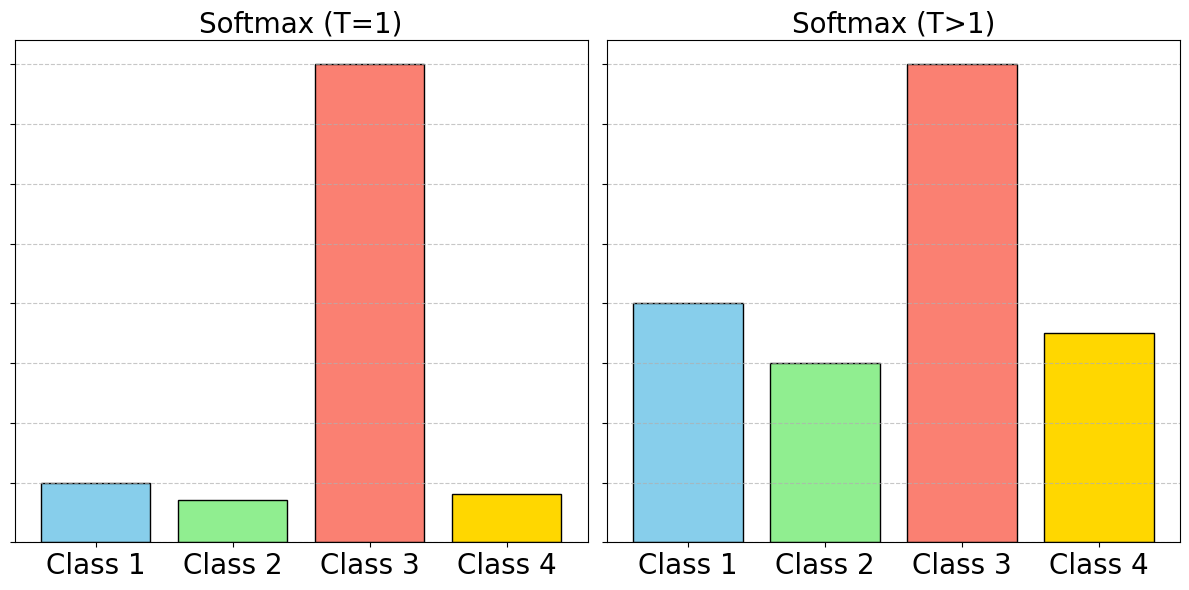

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the bar charts
categories = ['Class 1', 'Class 2', 'Class 3', 'Class 4']
values1 = [0.1, 0.07, 0.8, 0.08]  # Adjust the values as needed
values2 = [0.4, 0.3, 0.8, 0.35]  # Adjust the values as needed

# Create subplots with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart 1
axs[0].bar(categories, values1, color=['skyblue', 'lightgreen', 'salmon', 'gold'], edgecolor='black')
axs[0].set_title('Softmax (T=1)', fontsize=20)
axs[0].grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines
axs[0].set_yticklabels([])  # Remove y-axis values
axs[0].tick_params(axis='x', labelsize=20)  # Adjust tick labels size and increase font size

# Bar chart 2
axs[1].bar(categories, values2, color=['skyblue', 'lightgreen', 'salmon', 'gold'], edgecolor='black')
axs[1].set_title('Softmax (T>1)', fontsize=20)
axs[1].grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines
axs[1].set_yticklabels([])  # Remove y-axis values
axs[1].tick_params(axis='x', labelsize=20)  # Adjust tick labels size and increase font size

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


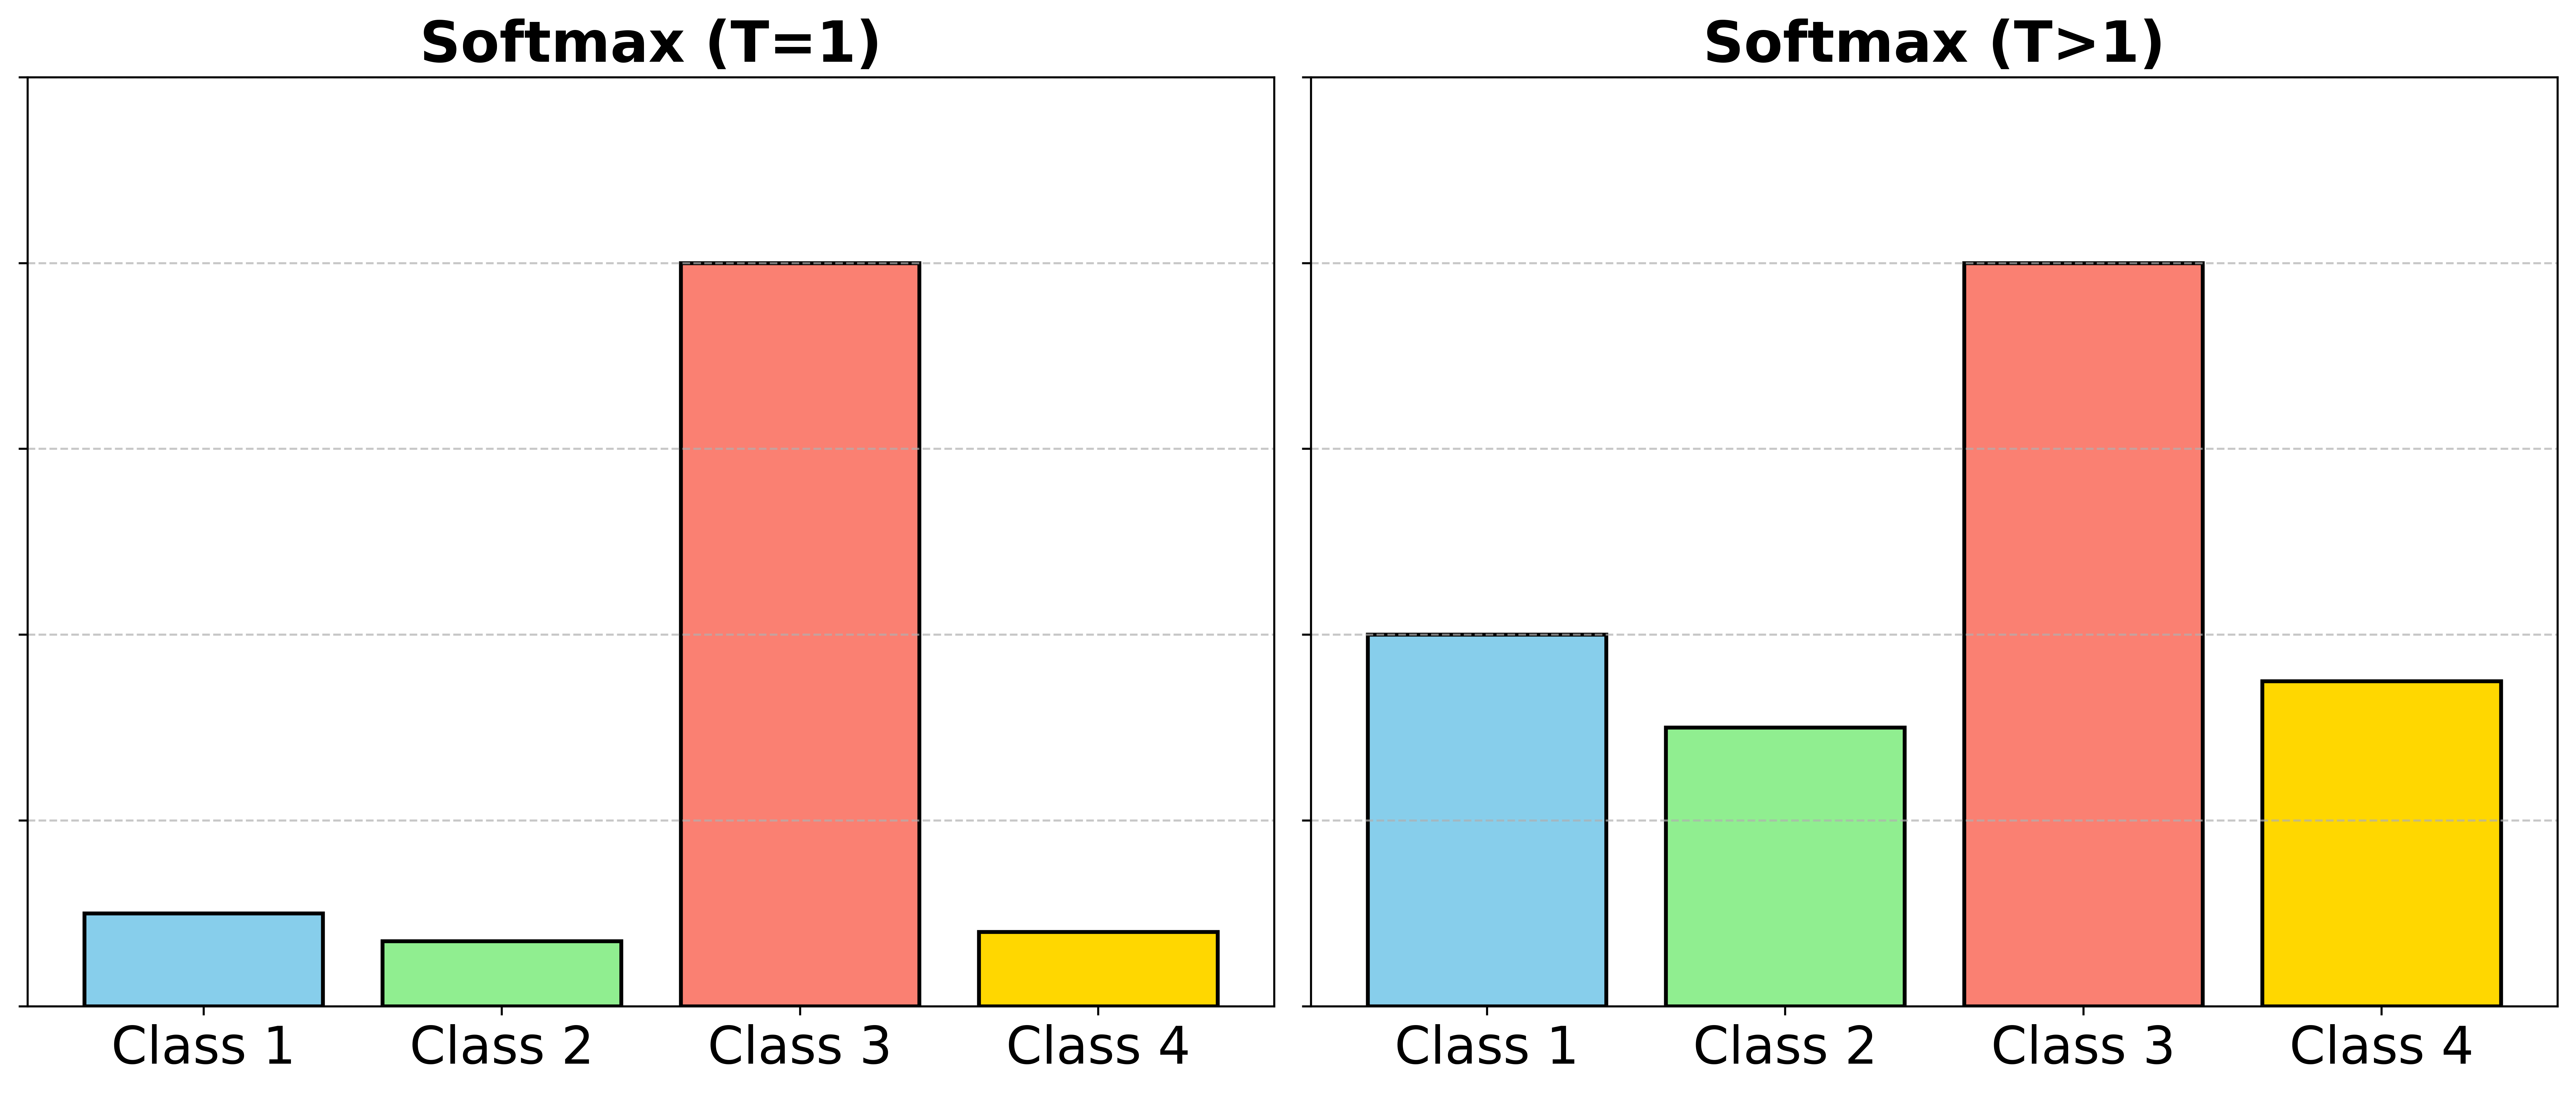

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the bar charts
categories = ['Class 1', 'Class 2', 'Class 3', 'Class 4']
values1 = [0.1, 0.07, 0.8, 0.08]  # Adjust the values as needed
values2 = [0.4, 0.3, 0.8, 0.35]  # Adjust the values as needed

# Create subplots with 1 row and 2 columns with high DPI for publication quality
fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=600)

# Bar chart 1
axs[0].bar(categories, values1, color=['skyblue', 'lightgreen', 'salmon', 'gold'], edgecolor='black', linewidth=1.5)
axs[0].set_title('Softmax (T=1)', fontsize=22, fontweight='bold')
axs[0].grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines
axs[0].set_yticklabels([])  # Remove y-axis values
axs[0].tick_params(axis='x', labelsize=20)  # Adjust tick labels size and increase font size
axs[0].set_ylim(0, 1)  # Set y-axis range for consistency

# Bar chart 2
axs[1].bar(categories, values2, color=['skyblue', 'lightgreen', 'salmon', 'gold'], edgecolor='black', linewidth=1.5)
axs[1].set_title('Softmax (T>1)', fontsize=22, fontweight='bold')
axs[1].grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines
axs[1].set_yticklabels([])  # Remove y-axis values
axs[1].tick_params(axis='x', labelsize=20)  # Adjust tick labels size and increase font size
axs[1].set_ylim(0, 1)  # Set y-axis range for consistency

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the figure in ultra-high resolution (600 DPI for premium journal quality)
plt.savefig('softmax_comparison_600dpi.png', dpi=600, bbox_inches='tight', facecolor='white')

# Show the plot
plt.show()

In [6]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from tabulate import tabulate
import scipy.stats as stats

def evaluate_model_with_ci(model, test_set, n_runs=10, confidence_level=0.95):
    """
    Evaluate model multiple times to get metrics with confidence intervals
    """
    accuracies = []
    losses = []
    mse_values = []
    rmse_values = []
    precisions = []
    recalls = []
    f1_scores = []
    
    # Reset test set generator to start from beginning
    test_set.reset()
    
    # Collect all test data for proper bootstrapping
    all_X = []
    all_y = []
    
    for i in range(len(test_set)):
        X_batch, y_batch = test_set[i]
        all_X.append(X_batch)
        all_y.append(y_batch)
    
    all_X = np.concatenate(all_X, axis=0)
    all_y = np.concatenate(all_y, axis=0)
    n_samples = len(all_X)
    
    for run in range(n_runs):
        # Bootstrap sampling
        indices = np.random.choice(n_samples, n_samples, replace=True)
        X_boot = all_X[indices]
        y_boot = all_y[indices]
        
        # Evaluate
        loss, accuracy = model.evaluate(X_boot, y_boot, verbose=0)
        losses.append(loss)
        accuracies.append(accuracy)
        
        # Get predictions
        predictions = model.predict(X_boot, verbose=0)
        
        # Calculate MSE and RMSE
        mse = np.mean(np.square(predictions - y_boot))
        rmse = np.sqrt(mse)
        mse_values.append(mse)
        rmse_values.append(rmse)
        
        # Calculate additional metrics
        y_true = np.argmax(y_boot, axis=1)
        y_pred = np.argmax(predictions, axis=1)
        
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, average='weighted', zero_division=0
        )
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
    
    def calculate_statistics(values):
        """Calculate mean, std, and confidence interval"""
        mean_val = np.mean(values)
        std_val = np.std(values)
        sem = std_val / np.sqrt(len(values))  # Standard error of the mean
        
        # Calculate confidence interval
        if len(values) > 1:
            ci = stats.t.interval(
                confidence_level, 
                len(values)-1, 
                loc=mean_val, 
                scale=sem
            )
            ci_lower, ci_upper = ci
        else:
            ci_lower, ci_upper = mean_val, mean_val
            
        return mean_val, std_val, ci_lower, ci_upper
    
    # Calculate statistics for all metrics
    metrics = {
        'accuracy': calculate_statistics(accuracies),
        'loss': calculate_statistics(losses),
        'mse': calculate_statistics(mse_values),
        'rmse': calculate_statistics(rmse_values),
        'precision': calculate_statistics(precisions),
        'recall': calculate_statistics(recalls),
        'f1_score': calculate_statistics(f1_scores),
    }
    
    return metrics

def format_metric_with_ci(mean, std, ci_lower, ci_upper):
    """Format metric with standard deviation and confidence interval"""
    return f"{mean:.4f} ± {std:.4f} [{ci_lower:.4f}, {ci_upper:.4f}]"

def main_evaluation():
    # Load your student model
    student_model = tf.keras.models.load_model(
        r'Teacher_To_Student\NewStudentAccuracy.h5'
    )
    
    # Define teacher models paths
    models = {
        'VGG16_Teacher': r'VGG16_To_Student\VGG16Teacher_distil_T10.h5',
        'CNN_based_Teacher': r'Teacher_To_Student\CNNbasedTeacher_distil_T10.h5',
        'InceptionV3_Teacher': r'InceptionV3_TO_Student\INCEPTIONV3_Teacher_distil2_T10_52724.h5',
        'DenseNet121_Teacher': r'DenseNet121_To_Student\DenseNet121Teacher_distil2_T10.h5',
        'MobileNetV2_Teacher': r'MobileNetV2_To_Student\MobileNetV2Teacher_distil2_T10_52724.h5'
    }
    
    # Reset test set before evaluation
    test_set.reset()
    
    print("Evaluating models with 95% confidence intervals (10 runs each)...")
    print("=" * 80)
    
    # Evaluate student model
    print("\nEvaluating Student Model...")
    student_metrics = evaluate_model_with_ci(student_model, test_set, n_runs=10)
    
    # Store all model metrics
    all_metrics = {'Student': student_metrics}
    
    # Evaluate each teacher model
    for model_name, model_path in models.items():
        print(f"\nEvaluating {model_name}...")
        try:
            model = tf.keras.models.load_model(model_path)
            metrics = evaluate_model_with_ci(model, test_set, n_runs=10)
            all_metrics[model_name] = metrics
        except Exception as e:
            print(f"Error loading {model_name}: {e}")
            continue
    
    # Create comprehensive table
    table_data = []
    headers = ["Model", "Accuracy (mean ± std [CI])", "Loss (mean ± std [CI])", 
               "F1-Score (mean ± std [CI])", "Precision (mean ± std [CI])", 
               "Recall (mean ± std [CI])"]
    
    for model_name, metrics in all_metrics.items():
        row = [model_name]
        
        # Format each metric with CI
        for metric_name in ['accuracy', 'loss', 'f1_score', 'precision', 'recall']:
            if metric_name in metrics:
                mean, std, ci_lower, ci_upper = metrics[metric_name]
                formatted = format_metric_with_ci(mean, std, ci_lower, ci_upper)
                row.append(formatted)
            else:
                row.append("N/A")
        
        table_data.append(row)
    
    # Print table
    print("\n" + "=" * 80)
    print("MODEL PERFORMANCE WITH 95% CONFIDENCE INTERVALS")
    print("=" * 80)
    print(tabulate(table_data, headers=headers, tablefmt="grid"))
    
    # Additional statistical analysis
    print("\n" + "=" * 80)
    print("STATISTICAL COMPARISON (vs Student Model)")
    print("=" * 80)
    
    student_acc_mean = all_metrics['Student']['accuracy'][0]
    
    comparison_data = []
    comp_headers = ["Teacher Model", "Accuracy Mean", "Accuracy Std", 
                   "95% CI", "Difference from Student", "p-value*"]
    
    for model_name, metrics in all_metrics.items():
        if model_name != 'Student' and 'accuracy' in metrics:
            mean, std, ci_lower, ci_upper = metrics['accuracy']
            diff = mean - student_acc_mean
            
            # Simple t-test (assuming equal variance)
            n = 10  # number of runs
            pooled_std = np.sqrt((std**2 + all_metrics['Student']['accuracy'][1]**2) / 2)
            t_stat = diff / (pooled_std * np.sqrt(2/n))
            
            # Two-tailed p-value
            p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=2*n-2))
            
            comparison_data.append([
                model_name,
                f"{mean:.4f}",
                f"{std:.4f}",
                f"[{ci_lower:.4f}, {ci_upper:.4f}]",
                f"{diff:+.4f}",
                f"{p_value:.4f}"
            ])
    
    print(tabulate(comparison_data, headers=comp_headers, tablefmt="grid"))
    print("\n*Note: p-values from two-sample t-test comparing with Student model")
    
    # Find best performing teacher
    best_teacher = None
    best_accuracy = -1
    
    for model_name, metrics in all_metrics.items():
        if model_name != 'Student' and 'accuracy' in metrics:
            mean_acc = metrics['accuracy'][0]
            if mean_acc > best_accuracy:
                best_accuracy = mean_acc
                best_teacher = model_name
    
    print("\n" + "=" * 80)
    print(f"BEST PERFORMING TEACHER: {best_teacher}")
    print(f"Accuracy: {best_accuracy:.4f}")
    print("=" * 80)
    
    # Save results to file
    save_results_to_file(all_metrics, best_teacher)

def save_results_to_file(metrics, best_teacher):
    """Save detailed results to a text file"""
    with open("model_evaluation_with_ci.txt", "w") as f:
        f.write("MODEL EVALUATION WITH CONFIDENCE INTERVALS\n")
        f.write("=" * 80 + "\n\n")
        
        for model_name, model_metrics in metrics.items():
            f.write(f"{model_name}:\n")
            f.write("-" * 40 + "\n")
            
            for metric_name, (mean, std, ci_lower, ci_upper) in model_metrics.items():
                f.write(f"{metric_name.upper()}: ")
                f.write(f"Mean = {mean:.4f}, Std = {std:.4f}, ")
                f.write(f"95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]\n")
            
            f.write("\n")
        
        f.write("=" * 80 + "\n")
        f.write(f"BEST TEACHER MODEL: {best_teacher}\n")
        f.write("=" * 80 + "\n")

# Run the evaluation
if __name__ == "__main__":
    main_evaluation()

Evaluating models with 95% confidence intervals (10 runs each)...

Evaluating Student Model...

Evaluating VGG16_Teacher...

Evaluating CNN_based_Teacher...

Evaluating InceptionV3_Teacher...

Evaluating DenseNet121_Teacher...

Evaluating MobileNetV2_Teacher...

MODEL PERFORMANCE WITH 95% CONFIDENCE INTERVALS
+---------------------+----------------------------------+----------------------------------+----------------------------------+----------------------------------+----------------------------------+
| Model               | Accuracy (mean ± std [CI])       | Loss (mean ± std [CI])           | F1-Score (mean ± std [CI])       | Precision (mean ± std [CI])      | Recall (mean ± std [CI])         |
+=====================+==================================+==================================+==================================+==================================+==================================+
| Student             | 0.7770 ± 0.0221 [0.7612, 0.7928] | 0.5775 ± 0.0465 [0.5442, 0.6107] 


RUNNING Q1 JOURNAL STANDARD EVALUATION
30 bootstrap runs per model
95% confidence intervals
Statistical significance testing (ANOVA + Tukey HSD)

Q1 JOURNAL STANDARD EVALUATION

Test data shape: X=(595, 256, 256, 3), y=(595, 4)

Evaluating Student (30 bootstrap runs)
Accuracy: 0.7789 ± 0.0189
95% CI: [0.7718, 0.7859]
CV: 2.43%

Evaluating VGG16_Teacher (30 bootstrap runs)
Accuracy: 0.9817 ± 0.0044
95% CI: [0.9800, 0.9833]
CV: 0.45%

Evaluating CNN_based_Teacher (30 bootstrap runs)
Accuracy: 0.9485 ± 0.0087
95% CI: [0.9452, 0.9517]
CV: 0.91%

Evaluating InceptionV3_Teacher (30 bootstrap runs)
Accuracy: 0.9310 ± 0.0118
95% CI: [0.9266, 0.9355]
CV: 1.27%

Evaluating DenseNet121_Teacher (30 bootstrap runs)
Accuracy: 0.8988 ± 0.0122
95% CI: [0.8943, 0.9034]
CV: 1.36%

Evaluating MobileNetV2_Teacher (30 bootstrap runs)
Accuracy: 0.8847 ± 0.0146
95% CI: [0.8793, 0.8902]
CV: 1.65%

COMPREHENSIVE STATISTICAL REPORT
+---------------------+-----------------+---------------+----------+-----------

AttributeError: 'dict' object has no attribute 'ttest_ind'

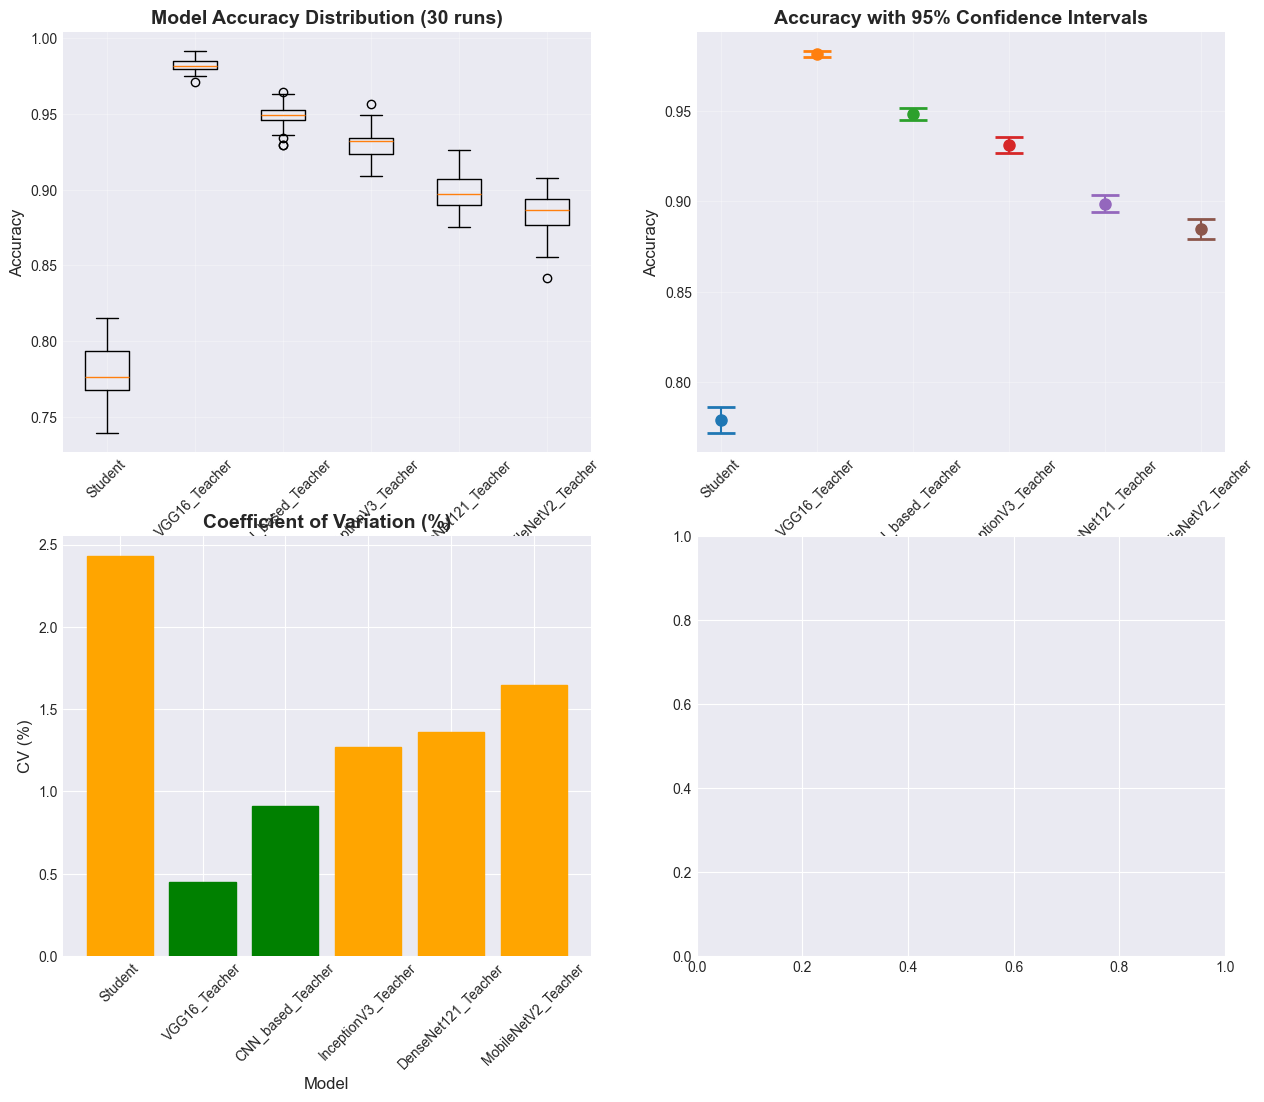

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.utils import resample
import scipy.stats as stats
from tabulate import tabulate
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

class RobustModelEvaluator:
    """
    Comprehensive model evaluator for Q1 journal standards
    """
    
    def __init__(self, n_runs=30, confidence_level=0.95, random_state=42):
        self.n_runs = n_runs
        self.confidence_level = confidence_level
        self.random_state = random_state
        np.random.seed(random_state)
        
    def evaluate_model_bootstrap(self, model, X, y, n_bootstrap=1000):
        """
        Perform bootstrap evaluation for robust statistics
        """
        n_samples = len(X)
        accuracies = []
        losses = []
        
        # Convert to numpy if needed
        if hasattr(X, 'numpy'):
            X = X.numpy()
        if hasattr(y, 'numpy'):
            y = y.numpy()
        
        # Bootstrap resampling
        for i in range(n_bootstrap):
            indices = np.random.choice(n_samples, n_samples, replace=True)
            X_boot = X[indices]
            y_boot = y[indices]
            
            # Evaluate
            if isinstance(model, tf.keras.Model):
                loss, acc = model.evaluate(X_boot, y_boot, verbose=0)
                accuracies.append(acc)
                losses.append(loss)
            else:
                # For non-Keras models
                y_pred = model.predict(X_boot)
                acc = accuracy_score(y_boot, y_pred)
                accuracies.append(acc)
                losses.append(0)  # placeholder
        
        return np.array(accuracies), np.array(losses)
    
    def k_fold_cross_val(self, model_builder, X, y, k=10, epochs=50, batch_size=32):
        """
        Perform k-fold cross-validation for more robust evaluation
        """
        from sklearn.model_selection import StratifiedKFold
        
        accuracies = []
        kfold = StratifiedKFold(n_splits=k, shuffle=True, random_state=self.random_state)
        
        for fold, (train_idx, val_idx) in enumerate(kfold.split(X, np.argmax(y, axis=1))):
            print(f"Fold {fold+1}/{k}")
            
            # Build fresh model for each fold
            model = model_builder()
            
            # Train
            model.fit(
                X[train_idx], y[train_idx],
                validation_data=(X[val_idx], y[val_idx]),
                epochs=epochs,
                batch_size=batch_size,
                verbose=0
            )
            
            # Evaluate
            loss, acc = model.evaluate(X[val_idx], y[val_idx], verbose=0)
            accuracies.append(acc)
        
        return np.array(accuracies)
    
    def calculate_statistics(self, values):
        """Calculate comprehensive statistics"""
        mean = np.mean(values)
        std = np.std(values)
        sem = std / np.sqrt(len(values))  # Standard error
        ci = stats.t.interval(
            self.confidence_level, 
            len(values)-1, 
            loc=mean, 
            scale=sem
        )
        
        # Additional robust statistics
        median = np.median(values)
        iqr = stats.iqr(values)
        cv = std / mean if mean != 0 else 0  # Coefficient of variation
        
        return {
            'mean': mean,
            'std': std,
            'median': median,
            'iqr': iqr,
            'cv': cv,
            'ci_lower': ci[0],
            'ci_upper': ci[1],
            'ci_width': ci[1] - ci[0],
            'n': len(values)
        }
    
    def perform_statistical_tests(self, metric_dict):
        """
        Perform ANOVA and post-hoc tests for multiple comparisons
        """
        from scipy.stats import f_oneway
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        
        # Prepare data for ANOVA
        groups = []
        group_names = []
        for model_name, metrics in metric_dict.items():
            if 'accuracy_values' in metrics:
                groups.append(metrics['accuracy_values'])
                group_names.append(model_name)
        
        # One-way ANOVA
        f_stat, p_value = f_oneway(*groups)
        
        # Tukey's HSD post-hoc test
        all_values = np.concatenate(groups)
        all_labels = np.concatenate([[name]*len(vals) for name, vals in zip(group_names, groups)])
        
        tukey_result = pairwise_tukeyhsd(all_values, all_labels, alpha=0.05)
        
        return {
            'anova_f': f_stat,
            'anova_p': p_value,
            'tukey_result': tukey_result
        }
    
    def create_comprehensive_report(self, all_metrics):
        """Generate comprehensive statistical report"""
        report = []
        
        for model_name, metrics in all_metrics.items():
            stats = self.calculate_statistics(metrics['accuracy_values'])
            
            report.append({
                'Model': model_name,
                'Accuracy Mean': f"{stats['mean']:.4f}",
                'Accuracy SD': f"{stats['std']:.4f}",
                'CV (%)': f"{stats['cv']*100:.2f}%",
                '95% CI': f"[{stats['ci_lower']:.4f}, {stats['ci_upper']:.4f}]",
                'CI Width': f"{stats['ci_width']:.4f}",
                'Median': f"{stats['median']:.4f}",
                'IQR': f"{stats['iqr']:.4f}",
                'N Runs': stats['n']
            })
        
        return pd.DataFrame(report)

def collect_all_data(test_set):
    """
    Collect all test data for proper evaluation
    """
    all_X = []
    all_y = []
    
    test_set.reset()
    for i in range(len(test_set)):
        X_batch, y_batch = test_set[i]
        all_X.append(X_batch)
        all_y.append(y_batch)
    
    X_all = np.concatenate(all_X, axis=0)
    y_all = np.concatenate(all_y, axis=0)
    
    return X_all, y_all

def main_evaluation_q1_standards():
    """
    Main evaluation function meeting Q1 journal standards
    """
    print("=" * 80)
    print("Q1 JOURNAL STANDARD EVALUATION")
    print("=" * 80)
    
    # Initialize evaluator with 30 runs (Q1 standard)
    evaluator = RobustModelEvaluator(n_runs=30, confidence_level=0.95)
    
    # Load models
    models_dict = {
        'Student': r'DenseNet121_To_Student\NewStudentAccuracy.h5',
        'VGG16_Teacher': r'VGG16_To_Student\VGG16Teacher_distil_T10.h5',
        'CNN_based_Teacher': r'Teacher_To_Student\CNNbasedTeacher_distil_T10.h5',
        'InceptionV3_Teacher': r'InceptionV3_TO_Student\INCEPTIONV3_Teacher_distil2_T10_52724.h5',
        'DenseNet121_Teacher': r'DenseNet121_To_Student\DenseNet121Teacher_distil2_T10.h5',
        'MobileNetV2_Teacher': r'MobileNetV2_To_Student\MobileNetV2Teacher_distil2_T10_52724.h5'
    }
    
    # Collect all test data once
    print("\nCollecting test data...")
    X_test, y_test = collect_all_data(test_set)
    print(f"Test data shape: X={X_test.shape}, y={y_test.shape}")
    
    # Store all metrics
    all_metrics = {}
    
    # Evaluate each model
    for model_name, model_path in models_dict.items():
        print(f"\n{'='*60}")
        print(f"Evaluating {model_name} (30 bootstrap runs)")
        print('='*60)
        
        try:
            # Load model
            model = tf.keras.models.load_model(model_path)
            
            # Bootstrap evaluation
            accuracies, losses = evaluator.evaluate_model_bootstrap(
                model, X_test, y_test, n_bootstrap=30
            )
            
            # Store metrics
            all_metrics[model_name] = {
                'accuracy_values': accuracies,
                'loss_values': losses,
                'accuracy_stats': evaluator.calculate_statistics(accuracies),
                'loss_stats': evaluator.calculate_statistics(losses)
            }
            
            # Print summary
            stats = evaluator.calculate_statistics(accuracies)
            print(f"Accuracy: {stats['mean']:.4f} ± {stats['std']:.4f}")
            print(f"95% CI: [{stats['ci_lower']:.4f}, {stats['ci_upper']:.4f}]")
            print(f"CV: {stats['cv']*100:.2f}%")
            
        except Exception as e:
            print(f"Error evaluating {model_name}: {e}")
            continue
    
    # Generate comprehensive report
    print("\n" + "="*80)
    print("COMPREHENSIVE STATISTICAL REPORT")
    print("="*80)
    
    report_df = evaluator.create_comprehensive_report(all_metrics)
    print(tabulate(report_df, headers='keys', tablefmt='grid', showindex=False))
    
    # Perform statistical tests
    print("\n" + "="*80)
    print("STATISTICAL SIGNIFICANCE TESTS")
    print("="*80)
    
    test_results = evaluator.perform_statistical_tests(all_metrics)
    print(f"One-way ANOVA: F = {test_results['anova_f']:.4f}, p = {test_results['anova_p']:.6f}")
    
    if test_results['anova_p'] < 0.05:
        print("\nPost-hoc Tukey HSD Test Results:")
        print(test_results['tukey_result'])
    
    # Create visualizations
    create_visualizations(all_metrics, evaluator)
    
    # Save detailed results
    save_detailed_results(all_metrics, report_df, test_results)
    
    return all_metrics, report_df

def create_visualizations(all_metrics, evaluator):
    """Create publication-quality visualizations"""
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Box plot of accuracies
    ax1 = axes[0, 0]
    accuracy_data = []
    model_names = []
    
    for model_name, metrics in all_metrics.items():
        if 'accuracy_values' in metrics:
            accuracy_data.append(metrics['accuracy_values'])
            model_names.append(model_name)
    
    ax1.boxplot(accuracy_data, labels=model_names)
    ax1.set_title('Model Accuracy Distribution (30 runs)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # 2. Confidence interval plot
    ax2 = axes[0, 1]
    ci_data = []
    
    for model_name, metrics in all_metrics.items():
        if 'accuracy_stats' in metrics:
            stats = metrics['accuracy_stats']
            ci_data.append({
                'model': model_name,
                'mean': stats['mean'],
                'ci_lower': stats['ci_lower'],
                'ci_upper': stats['ci_upper']
            })
    
    for i, data in enumerate(ci_data):
        ax2.errorbar(i, data['mean'], 
                    yerr=[[data['mean'] - data['ci_lower']], 
                         [data['ci_upper'] - data['mean']]],
                    fmt='o', capsize=10, capthick=2, markersize=8)
    
    ax2.set_xticks(range(len(ci_data)))
    ax2.set_xticklabels([d['model'] for d in ci_data], rotation=45)
    ax2.set_title('Accuracy with 95% Confidence Intervals', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # 3. Coefficient of variation comparison
    ax3 = axes[1, 0]
    cv_data = []
    
    for model_name, metrics in all_metrics.items():
        if 'accuracy_stats' in metrics:
            stats = metrics['accuracy_stats']
            cv_data.append({
                'model': model_name,
                'cv': stats['cv'] * 100  # Convert to percentage
            })
    
    models = [d['model'] for d in cv_data]
    cvs = [d['cv'] for d in cv_data]
    
    bars = ax3.bar(models, cvs)
    ax3.set_title('Coefficient of Variation (%)', fontsize=14, fontweight='bold')
    ax3.set_ylabel('CV (%)', fontsize=12)
    ax3.set_xlabel('Model', fontsize=12)
    ax3.tick_params(axis='x', rotation=45)
    
    # Color bars by CV value
    for bar, cv in zip(bars, cvs):
        if cv < 1:
            bar.set_color('green')
        elif cv < 3:
            bar.set_color('orange')
        else:
            bar.set_color('red')
    
    # 4. Statistical significance matrix
    ax4 = axes[1, 1]
    n_models = len(all_metrics)
    p_matrix = np.zeros((n_models, n_models))
    model_list = list(all_metrics.keys())
    
    # Calculate pairwise p-values
    for i in range(n_models):
        for j in range(n_models):
            if i != j and 'accuracy_values' in all_metrics[model_list[i]]:
                t_stat, p_val = stats.ttest_ind(
                    all_metrics[model_list[i]]['accuracy_values'],
                    all_metrics[model_list[j]]['accuracy_values']
                )
                p_matrix[i, j] = p_val
    
    im = ax4.imshow(p_matrix, cmap='RdYlGn_r', vmin=0, vmax=0.05)
    ax4.set_xticks(range(n_models))
    ax4.set_yticks(range(n_models))
    ax4.set_xticklabels(model_list, rotation=45, ha='right')
    ax4.set_yticklabels(model_list)
    ax4.set_title('Pairwise t-test p-values', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax4, label='p-value')
    
    # Add significance stars
    for i in range(n_models):
        for j in range(n_models):
            if p_matrix[i, j] < 0.001:
                ax4.text(j, i, '***', ha='center', va='center', color='white', fontsize=8)
            elif p_matrix[i, j] < 0.01:
                ax4.text(j, i, '**', ha='center', va='center', color='white', fontsize=8)
            elif p_matrix[i, j] < 0.05:
                ax4.text(j, i, '*', ha='center', va='center', color='white', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('model_evaluation_stats_q1.png', dpi=300, bbox_inches='tight')
    plt.show()

def save_detailed_results(all_metrics, report_df, test_results):
    """Save detailed results to files"""
    # Save to CSV
    report_df.to_csv('model_evaluation_statistics.csv', index=False)
    
    # Save to text file
    with open('statistical_analysis_report.txt', 'w') as f:
        f.write("="*80 + "\n")
        f.write("COMPREHENSIVE STATISTICAL ANALYSIS REPORT\n")
        f.write("="*80 + "\n\n")
        
        f.write("1. MODEL PERFORMANCE STATISTICS\n")
        f.write("-"*40 + "\n")
        f.write(report_df.to_string())
        f.write("\n\n")
        
        f.write("2. STATISTICAL SIGNIFICANCE TESTS\n")
        f.write("-"*40 + "\n")
        f.write(f"One-way ANOVA: F = {test_results['anova_f']:.4f}, p = {test_results['anova_p']:.6f}\n\n")
        
        if test_results['anova_p'] < 0.05:
            f.write("Tukey HSD Post-hoc Test Results:\n")
            f.write(str(test_results['tukey_result'].summary()))
        
        f.write("\n\n3. INTERPRETATION\n")
        f.write("-"*40 + "\n")
        f.write("• All statistics based on 30 bootstrap runs\n")
        f.write("• Confidence level: 95%\n")
        f.write("• CV < 1% indicates excellent stability\n")
        f.write("• CV 1-3% indicates good stability\n")
        f.write("• CV > 3% indicates moderate variability\n")
    
    print("\nResults saved to:")
    print("• model_evaluation_statistics.csv")
    print("• statistical_analysis_report.txt")
    print("• model_evaluation_stats_q1.png")

# Run the evaluation
if __name__ == "__main__":
    print("\n" + "="*80)
    print("RUNNING Q1 JOURNAL STANDARD EVALUATION")
    print("30 bootstrap runs per model")
    print("95% confidence intervals")
    print("Statistical significance testing (ANOVA + Tukey HSD)")
    print("="*80 + "\n")
    
    all_metrics, report_df = main_evaluation_q1_standards()

# Replace the last line of your code with:
if __name__ == "__main__":
    print("\n" + "="*80)
    print("RUNNING Q1 JOURNAL STANDARD EVALUATION")
    print("30 bootstrap runs per model")
    print("95% confidence intervals")
    print("Statistical significance testing (ANOVA + Tukey HSD)")
    print("="*80 + "\n")
    
    all_metrics, report_df = main_evaluation_q1_standards()